In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 9, 21)) & (dataset.data.index < datetime.datetime(2024, 10, 20)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [4]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")
pipe = systemClasses.System(dataset=dataset, name="PIPE")
apa = systemClasses.System(dataset=dataset, name="APA")
pump = systemClasses.System(dataset=dataset, name="PP")
prm = systemClasses.System(dataset=dataset, name="PRM")
ga1 = systemClasses.System(dataset=dataset, name="GA-1")
ga2 = systemClasses.System(dataset=dataset, name="GA-2")
wall = systemClasses.System(dataset=dataset, name="WALL")

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 10.32sensor/s]


ERROR: Channel (TE0120) not found


Initializing WALL Sensors: 100%|██████████| 5/5 [00:00<00:00, 10.88sensor/s]


In [18]:
tgrad.calibrate(calibName="SECOND_POFF_EMPTY")
apa.calibrate(calibName="SECOND_POFF_OCTOBER")
pump.calibrate(calibName="SECOND_POFF_OCTOBER")
prm.calibrate(calibName="SECOND_POFF_OCTOBER")
hawai.calibrate(calibName="SECOND_POFF_EMPTY")
pipe.calibrate(calibName="SECOND_POFF_OCTOBER")
wall.calibrate(calibName="SECOND_POFF_OCTOBER")
# ga1.calibrate(calibName="FIRST_POFF_PIPES")
# ga2.calibrate(calibName="FIRST_POFF_PIPES")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  9.17sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 48/48 [00:00<00:00, 117.16sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 14.84sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 16/16 [00:00<00:00, 111.68sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00, 10.37sensor/s]
Calibrating PP Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 109.60sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  8.96sensor/s]
Calibrating PRM Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 6/6 [00:00<00:00, 116.69sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 10.36sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 24/24 [00:00<00:00, 110.90sensor/s]
Equalizing PIPE Sensors: 100%|██████

ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 106.21sensor/s]
Equalizing WALL Sensors: 100%|██████████| 5/5 [00:00<00:00,  8.56sensor/s]
Calibrating WALL Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 5/5 [00:00<00:00, 123.78sensor/s]

ERROR: SensorID (40066) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40067) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40068) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40069) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40070) not found in calibration (SECOND_POFF_OCTOBER)


In [6]:
pressure1 = sensorClasses.Sensor(dataset=dataset, id=1011)
pressure2 = sensorClasses.Sensor(dataset=dataset, id=1012)
ambient_pressure = sensorClasses.Sensor(dataset=dataset, id=1038)
pump_pressure = sensorClasses.Sensor(dataset=dataset, id=1048)
lar_pressure1 = sensorClasses.Sensor(dataset=dataset, id=1050)
lar_pressure2 = sensorClasses.Sensor(dataset=dataset, id=1051)
lar_flow = sensorClasses.Sensor(dataset=dataset, id=1049)
level1 = sensorClasses.Sensor(dataset=dataset, id=1040)
level2 = sensorClasses.Sensor(dataset=dataset, id=1041)
cryostat_height = 8550.4

(1.2, 2.1)

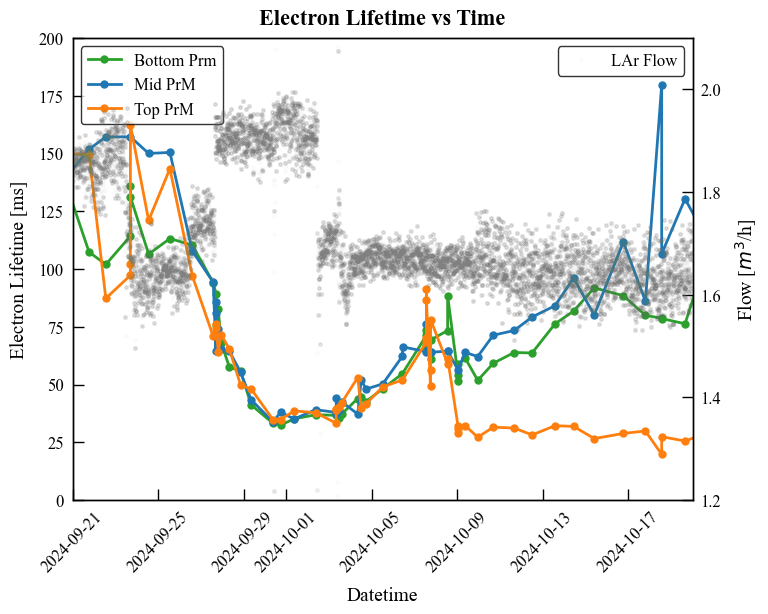

In [413]:
bot_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Bot_lifetime_data_calibration_database.csv", header=0)
bot_purity["Timestamp"] = pd.to_datetime(bot_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
bot_purity = bot_purity.set_index("Timestamp")

mid_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Mid_lifetime_data_calibration_database.csv", header=0)
mid_purity["Timestamp"] = pd.to_datetime(mid_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
mid_purity = mid_purity.set_index("Timestamp")

top_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Top_lifetime_data_calibration_database.csv", header=0)
top_purity["Timestamp"] = pd.to_datetime(top_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
top_purity = top_purity.set_index("Timestamp")

fig, axes = plt.subplots(figsize=(8, 6))
axes.plot(bot_purity.index.values, bot_purity["EleLifeTime_TPCCenter"], "-o", label="Bottom Prm", color="tab:green")
axes.plot(mid_purity.index.values, mid_purity["EleLifeTime_TPCCenter"], "-o", label="Mid PrM", color="tab:blue")
axes.plot(top_purity.index.values, top_purity["EleLifeTime_TPCCenter"], "-o", label="Top PrM", color="tab:orange")
axes.set_ylim(0,200)
axes.set_xlim(datetime.datetime(2024, 9, 21), datetime.datetime(2024, 10, 20))
axes.set_xlabel("Datetime")
axes.set_ylabel("Electron Lifetime [ms]")
axes.set_title("Electron Lifetime vs Time")
axes.legend(loc="upper left")
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(lar_flow.data.index, lar_flow.data.values, ".", label="LAr Flow", color="gray", alpha=.025)
axes2.set_ylabel(fr"Flow [$m^3$/h]")
axes2.legend(loc="upper right")
axes2.set_ylim(1.2, 2.1)

/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_15053/1320395509.py:23: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  axes.set_ylim(0,5000)


(7575.0, 7700.0)

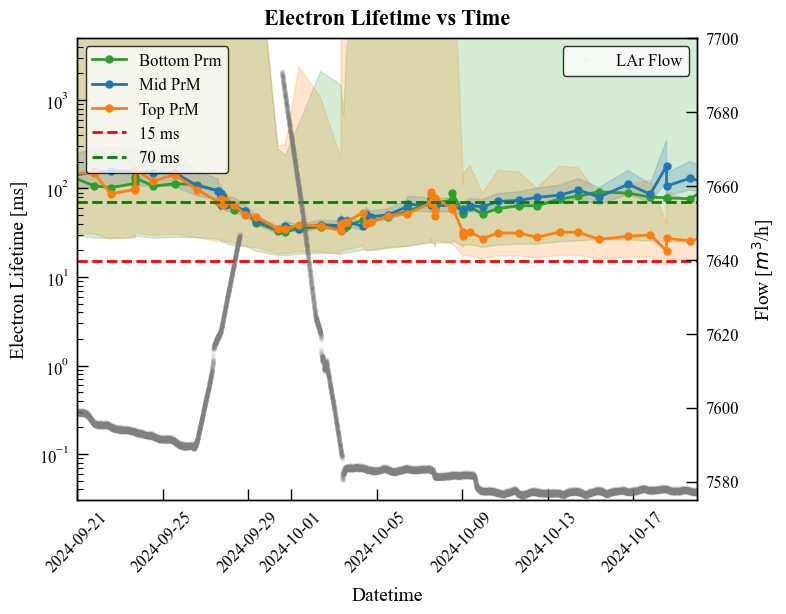

In [492]:
bot_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Bot_lifetime_data_calibration_database.csv", header=0)
bot_purity["Timestamp"] = pd.to_datetime(bot_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
bot_purity = bot_purity.set_index("Timestamp")

mid_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Mid_lifetime_data_calibration_database.csv", header=0)
mid_purity["Timestamp"] = pd.to_datetime(mid_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
mid_purity = mid_purity.set_index("Timestamp")

top_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Top_lifetime_data_calibration_database.csv", header=0)
top_purity["Timestamp"] = pd.to_datetime(top_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
top_purity = top_purity.set_index("Timestamp")

fig, axes = plt.subplots(figsize=(8, 6))
axes.plot(bot_purity.index.values, bot_purity["EleLifeTime_TPCCenter"], "-o", label="Bottom Prm", color="tab:green")
axes.plot(mid_purity.index.values, mid_purity["EleLifeTime_TPCCenter"], "-o", label="Mid PrM", color="tab:blue")
axes.plot(top_purity.index.values, top_purity["EleLifeTime_TPCCenter"], "-o", label="Top PrM", color="tab:orange")
axes.fill_between(bot_purity.index.values, bot_purity["EleLifeTime_TPCLow"], bot_purity["EleLifeTime_TPCHigh"], color="tab:green", alpha=0.2)
axes.fill_between(mid_purity.index.values, mid_purity["EleLifeTime_TPCLow"], mid_purity["EleLifeTime_TPCHigh"], color="tab:blue", alpha=0.2)
axes.fill_between(top_purity.index.values, top_purity["EleLifeTime_TPCLow"], top_purity["EleLifeTime_TPCHigh"], color="tab:orange", alpha=0.2)
axes.axhline(15, color="red", linestyle="--", label=fr"15 ms")
axes.axhline(70, color="green", linestyle="--", label=fr"70 ms")
axes.set_yscale("log")
axes.set_ylim(0,5000)
axes.set_xlim(datetime.datetime(2024, 9, 21), datetime.datetime(2024, 10, 20))
axes.set_xlabel("Datetime")
axes.set_ylabel("Electron Lifetime [ms]")
axes.set_title("Electron Lifetime vs Time")
axes.legend(loc="upper left")
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
# axes2.plot(level2.data.index, cryostat_height*level2.data.values/100, ".", label="LAr Flow", color="gray", alpha=.025)
axes2.plot(level1.data.index, level1.data.values, ".", label="LAr Flow", color="gray", alpha=.025)
axes2.set_ylabel(fr"Flow [$m^3$/h]")
axes2.legend(loc="upper right")
axes2.set_ylim(7575, 7700)

Text(0.5, 1.0, 'Cryostat and Ambient Pressure during Cryogenic Test')

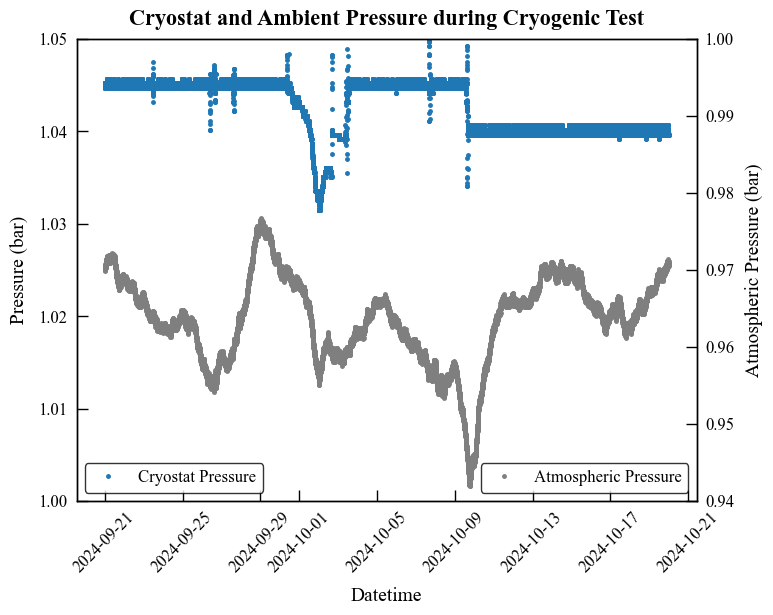

In [415]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:blue")
axes.set_ylim(1.0, 1.05)
axes2 = axes.twinx()
axes2.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, ".", label="Atmospheric Pressure", color="tab:gray", alpha=1)
axes2.set_ylim(0.94, 1.0)
axes2.set_ylabel("Atmospheric Pressure (bar)")
axes2.legend(loc="lower right")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.legend(loc="lower left")
axes.set_title("Cryostat and Ambient Pressure during Cryogenic Test")

Text(0.5, 1.0, 'Pump Differential Pressure and LAr Flow during Cryogenic Test')

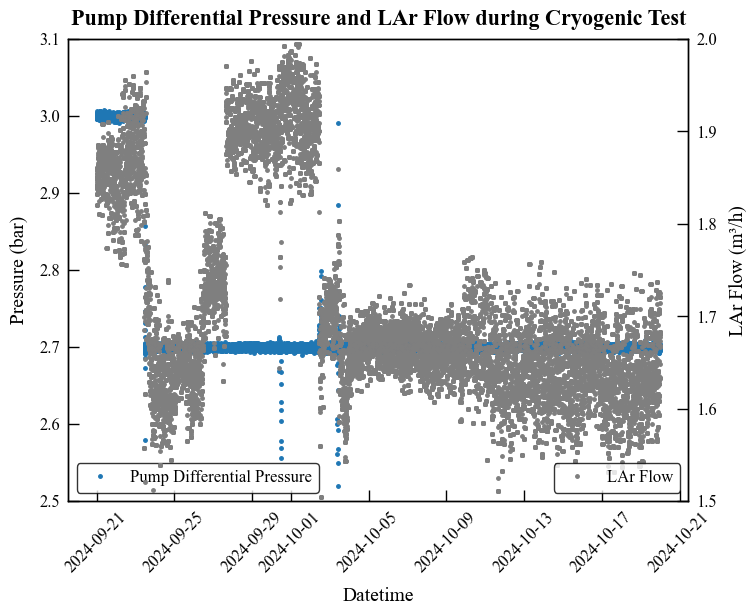

In [416]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pump_pressure.data.index, pump_pressure.data.values, ".", label="Pump Differential Pressure", color="tab:blue")
axes.set_ylim(2.5, 3.1)
axes2 = axes.twinx()
axes2.plot(lar_flow.data.index, lar_flow.data.values, ".", label="LAr Flow", color="tab:gray", alpha=1)
axes2.set_ylim(1.5, 2.0)
axes2.set_ylabel("LAr Flow (m³/h)")
axes2.legend(loc="lower right")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.legend(loc="lower left")
axes.set_title("Pump Differential Pressure and LAr Flow during Cryogenic Test")

Text(0.5, 1.0, 'LT0100 Level and Cryostat Pressure during Cryogenic Test')

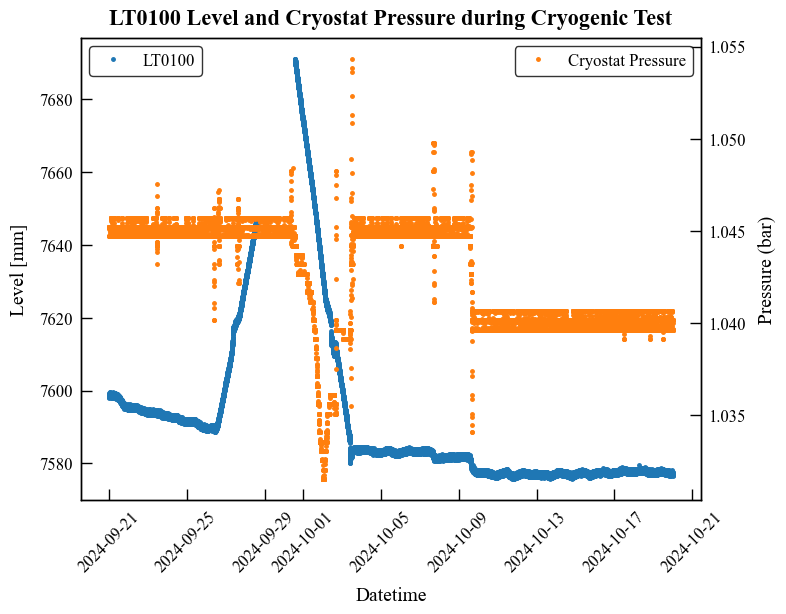

In [417]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes.tick_params(axis='x', rotation=45)
axes.legend(loc="upper left")
axes2 = axes.twinx()
axes2.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:orange")
axes2.set_ylabel("Pressure (bar)")
axes2.legend(loc="upper right")
axes.set_title("LT0100 Level and Cryostat Pressure during Cryogenic Test")
# axes.set_ylim(7550, 7650)

(7550.0, 7800.0)

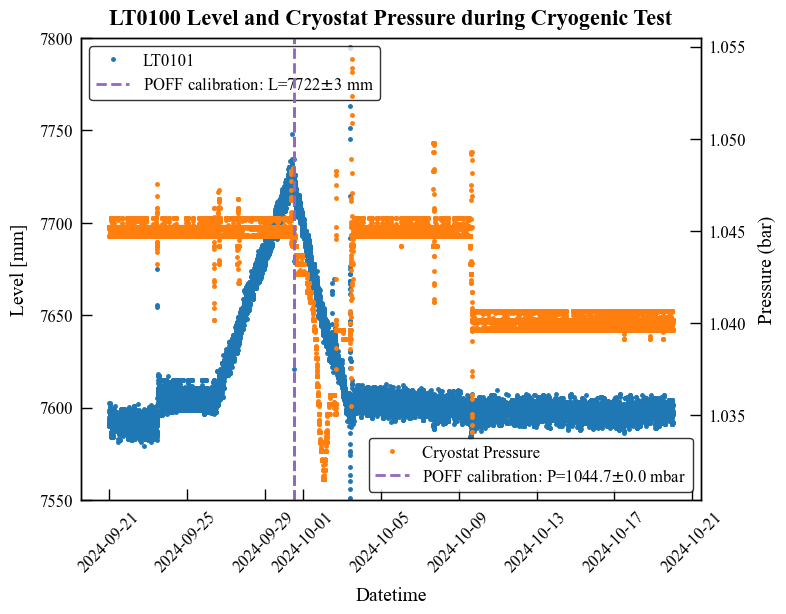

In [418]:
t4 = datetime.datetime(2024, 9, 30, 12)
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level2.data.index, cryostat_height*level2.data.values/100, ".", label="LT0101", color="tab:blue")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:orange")
axes2.set_ylabel("Pressure (bar)")
axes.set_title("LT0100 Level and Cryostat Pressure during Cryogenic Test")
axes.axvline(datetime.datetime(2024, 9, 30, 12, 0), color="tab:purple", linestyle="--", label=fr"POFF calibration: L={level2.data.loc[(level2.data.index > datetime.datetime(2024, 9, 30, 12, 0))&(level2.data.index<datetime.datetime(2024, 9, 30, 12, 30))].mean()*cryostat_height/100:.0f}$\pm${level2.data.loc[(level2.data.index > datetime.datetime(2024, 9, 30, 12, 0))&(level2.data.index<datetime.datetime(2024, 9, 30, 12, 30))].std()*cryostat_height/100:.0f} mm")
axes2.axvline(datetime.datetime(2024, 9, 30, 12, 0), color="tab:purple", linestyle="--", label=fr"POFF calibration: P={pressure1.data.loc[(pressure1.data.index > datetime.datetime(2024, 9, 30, 12, 0))&(pressure1.data.index<datetime.datetime(2024, 9, 30, 12, 30))].mean()*1000:.1f}$\pm${pressure1.data.loc[(pressure1.data.index > datetime.datetime(2024, 9, 30, 12, 0))&(pressure1.data.index<datetime.datetime(2024, 9, 30, 12, 30))].std()*1000:.1f} mbar")
axes.legend(loc="upper left")
axes2.legend(loc="lower right")
axes.set_ylim(7550, 7800)

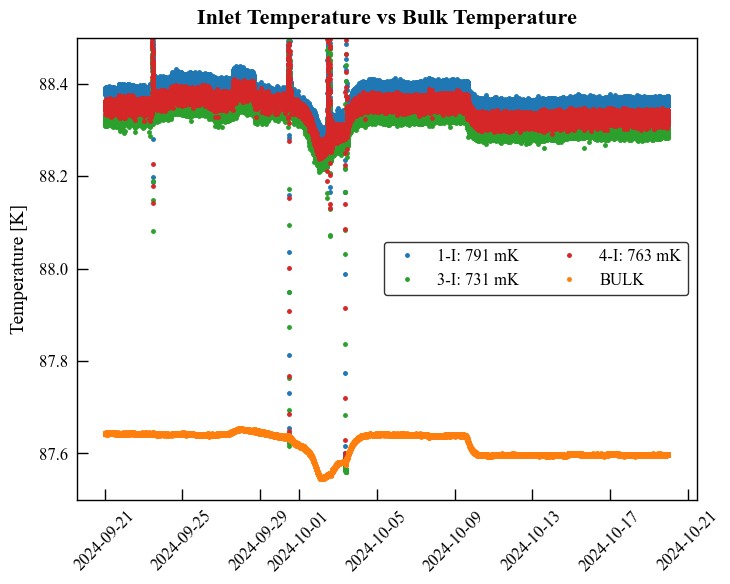

In [32]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pipe.sensors[49319].data.index, pipe.sensors[49319].data.values, ".", label=fr"{pipe.sensors[49319].name}: {1e3*(pipe.sensors[49319].data - tgrad.sensors[39607].data).mean():.0f} mK", color="tab:blue")
axes.plot(pipe.sensors[49321].data.index, pipe.sensors[49321].data.values, ".", label=fr"{pipe.sensors[49321].name}: {1e3*(pipe.sensors[49321].data - tgrad.sensors[39607].data).mean():.0f} mK", color="tab:green")
axes.plot(pipe.sensors[49322].data.index, pipe.sensors[49322].data.values, ".", label=fr"{pipe.sensors[49322].name}: {1e3*(pipe.sensors[49322].data - tgrad.sensors[39607].data).mean():.0f} mK", color="tab:red")
axes.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label=fr"BULK", color="tab:orange")
axes.set_ylim(87.5, 88.5)
axes.legend(loc="best", ncol=2)
axes.set_ylabel("Temperature [K]")
axes.set_title("Inlet Temperature vs Bulk Temperature")
axes.tick_params(axis='x', rotation=45)

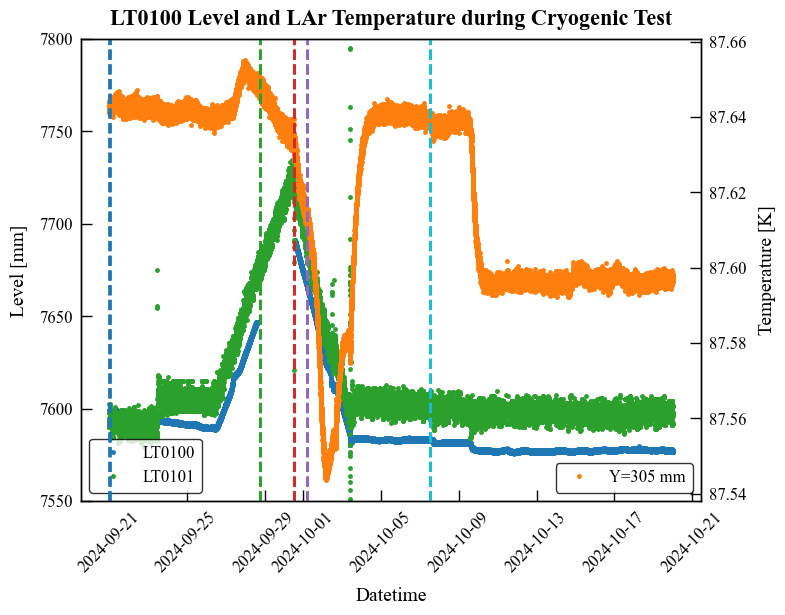

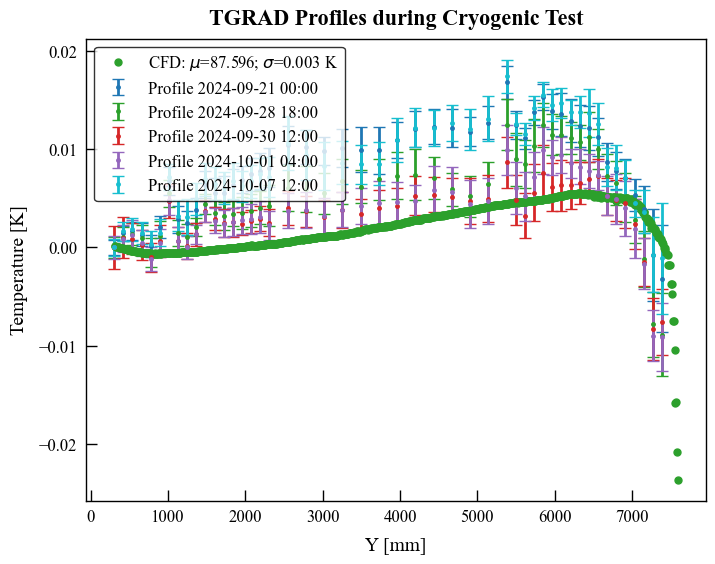

In [419]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.plot(level2.data.index, cryostat_height*level2.data.values/100, ".", label="LT0101", color="tab:green")
axes.legend(loc="lower left")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes.set_ylim(7550, 7800)
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label=fr"Y={tgrad.sensors[39607].Y:.0f} mm", color="tab:orange")
axes2.legend(loc="lower right")
axes2.set_ylabel("Temperature [K]")
axes.set_title("LT0100 Level and LAr Temperature during Cryogenic Test")
axes.tick_params(axis='x', rotation=45)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
deltat = datetime.timedelta(minutes=30)
t1 = datetime.datetime(2024, 9, 21, 0)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
axes2.axvline(t1, color="tab:blue", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t1 + deltat, color="tab:blue", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:blue")

# t2 = datetime.datetime(2024, 5, 14, 9)
# tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
# axes2.axvline(t2, color="tab:gray", linestyle="--", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')}")
# axes2.axvline(t2 + deltat, color="tab:gray", linestyle="--", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')} - {deltat}")
# axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')}", color="tab:orange")

t3 = datetime.datetime(2024, 9, 28, 18)
tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
axes2.axvline(t3, color="tab:green", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t3 + deltat, color="tab:green", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}", color="tab:green")

t4 = datetime.datetime(2024, 9, 30, 12)
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
axes2.axvline(t4, color="tab:red", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t4 + deltat, color="tab:red", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}", color="tab:red")

t5 = datetime.datetime(2024, 10, 1, 4)
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
axes2.axvline(t5, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t5 + deltat, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}", color="tab:purple")

t6 = datetime.datetime(2024, 10, 7, 12)
tgrad.makeProfiles(tini=t6, tend=t6 + deltat)
axes2.axvline(t6, color="tab:cyan", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t6 + deltat, color="tab:cyan", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}", color="tab:cyan")

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes.plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values - cfd.loc[(1e3*cfd.index>300)]["temp"].mean() + 0.002, 'o', label=fr'CFD: $\mu$={cfd.loc[(1e3*cfd.index>300)]["temp"].mean():.3f}; $\sigma$={cfd.loc[(1e3*cfd.index>300)]["temp"].std():.3f} K', color="tab:green")

axes.set_xlabel("Y [mm]")
axes.set_ylabel("Temperature [K]")
axes.set_title("TGRAD Profiles during Cryogenic Test")
axes.legend(loc="upper left")

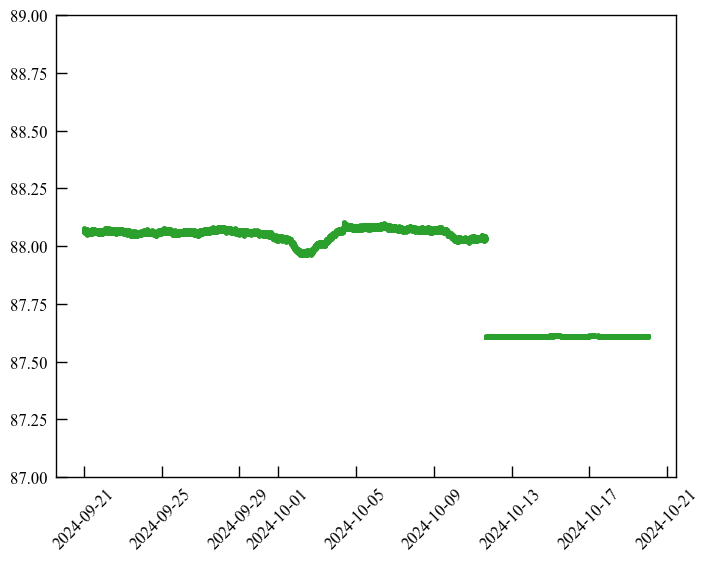

In [420]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(apa.sensors[44125].data.index, apa.sensors[44125].data.values, ".", label=fr"Y={apa.sensors[44125].Y:.0f} mm", color="tab:green")
axes.set_ylim(87,89)
axes.tick_params(axis='x', rotation=45)

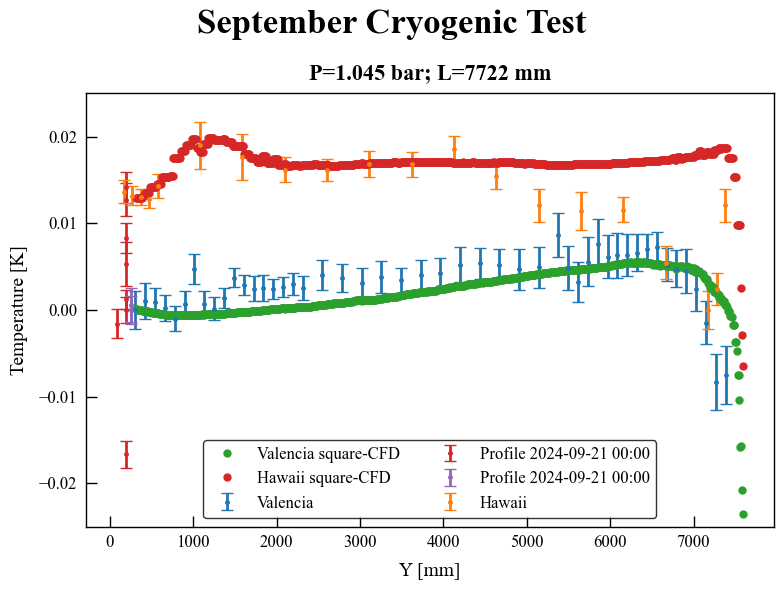

In [421]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
deltat = datetime.timedelta(minutes=30)
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
axes.errorbar(tgrad.profiles["Y"].values, (tgrad.profiles["temp"]-tgrad.profiles["temp"].values[-1]).values, yerr=tgrad.profiles["err"].values, fmt=".", label=f"Valencia", color="tab:blue")
apa.makeProfiles(tini=t4, tend=t4 + deltat)
# axes.errorbar(apa.profiles["Y"].values, (apa.profiles["temp"]-apa.profiles["temp"].values[-1]).values, yerr=apa.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:orange")
prm.makeProfiles(tini=t4, tend=t4 + deltat)
# axes.errorbar(prm.profiles["Y"].values, (prm.profiles["temp"]-prm.profiles["temp"].values[-1]).values, yerr=prm.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:green")
pipe.makeProfiles(tini=t4, tend=t4 + deltat)
axes.errorbar(pipe.profiles["Y"].values, (pipe.profiles["temp"]-pipe.profiles["temp"].values[-1]).values, yerr=pipe.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:red")
pump.makeProfiles(tini=t4, tend=t4 + deltat)
axes.errorbar(pump.profiles["Y"].values, (pump.profiles["temp"]-pump.profiles["temp"].values[-1]).values, yerr=pump.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:purple")
hawai.makeProfiles(tini=t4, tend=t4 + deltat)
axes.errorbar(hawai.profiles["Y"].values, (hawai.profiles["temp"]-hawai.profiles["temp"].values[-1]).values, yerr=hawai.profiles["err"].values, fmt=".", label=f"Hawaii", color="tab:orange")
axes.set_xlabel("Y [mm]")
axes.set_ylabel("Temperature [K]")

p5 = pressure1.data.loc[(pressure1.data.index >= t4) & (pressure1.data.index < t4 + deltat)].mean()
l5 = cryostat_height*level2.data.loc[(level1.data.index >= t4) & (level1.data.index < t4 + deltat)].mean()/100

fig.suptitle("September Cryogenic Test", fontsize=25, fontweight="bold")
axes.set_title(f"P={p5:.3f} bar; L={l5:.0f} mm")

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes.plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values - cfd.loc[(1e3*cfd.index>300)]["temp"].mean() + 0.002, 'o', label=fr'Valencia square-CFD', color="tab:green")

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes.plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values - cfd.loc[(1e3*cfd.index>300)]["temp"].mean() + 0.017, 'o', label=fr'Hawaii square-CFD', color="tab:red")
axes.legend(loc="best", ncol=2)
axes.set_ylim(-0.025,0.025)
fig.tight_layout()

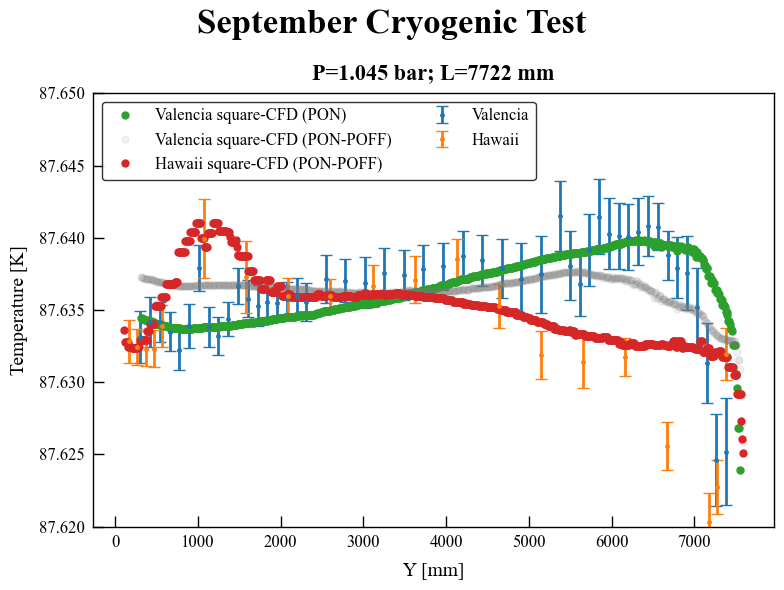

In [422]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
deltat = datetime.timedelta(minutes=60)
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
axes.errorbar(tgrad.profiles["Y"].values, (tgrad.profiles["temp"]).values, yerr=tgrad.profiles["err"].values, fmt=".", label=f"Valencia", color="tab:blue")
apa.makeProfiles(tini=t4, tend=t4 + deltat)
# axes.errorbar(apa.profiles["Y"].values, (apa.profiles["temp"]-apa.profiles["temp"].values[-1]).values, yerr=apa.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:orange")
prm.makeProfiles(tini=t4, tend=t4 + deltat)
# axes.errorbar(prm.profiles["Y"].values, (prm.profiles["temp"]-prm.profiles["temp"].values[-1]).values, yerr=prm.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:green")
pipe.makeProfiles(tini=t4, tend=t4 + deltat)
# axes.errorbar(pipe.profiles["Y"].values, (pipe.profiles["temp"]).values, yerr=pipe.profiles["err"].values, fmt=".", label=f"Pipe", color="tab:red")
pump.makeProfiles(tini=t4, tend=t4 + deltat)
# axes.errorbar(pump.profiles["Y"].values, (pump.profiles["temp"]).values, yerr=pump.profiles["err"].values, fmt=".", label=f"Pump", color="tab:purple")
hawai.makeProfiles(tini=t4, tend=t4 + deltat)
axes.errorbar(hawai.profiles["Y"].values, (hawai.profiles["temp"]).values, yerr=hawai.profiles["err"].values, fmt=".", label=f"Hawaii", color="tab:orange")
axes.set_xlabel("Y [mm]")
axes.set_ylabel("Temperature [K]")

p5 = pressure1.data.loc[(pressure1.data.index >= t4) & (pressure1.data.index < t4 + deltat)].mean()
l5 = cryostat_height*level2.data.loc[(level1.data.index >= t4) & (level1.data.index < t4 + deltat)].mean()/100

fig.suptitle("September Cryogenic Test", fontsize=25, fontweight="bold")
axes.set_title(f"P={p5:.3f} bar; L={l5:.0f} mm")

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes.plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values + 0.040, 'o', label=fr'Valencia square-CFD (PON)', color="tab:green")
# axes.plot(1e3*cfd_poff.loc[(1e3*cfd.index>300)].index.values, cfd_poff.loc[(1e3*cfd_poff.index>300)]["temp"].values + 0.035, 'o', label=fr'Valencia square-CFD', color="tab:gray")
axes.plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, (cfd.loc[(1e3*cfd.index>300)]["temp"] - cfd_poff.loc[(1e3*cfd.index>300)]["temp"] + cfd_poff.loc[(1e3*cfd.index>300)]["temp"].mean()).values + 0.040, 'o', label=fr'Valencia square-CFD (PON-POFF)', color="tab:gray", alpha=0.1)

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
# axes.plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values + 0.020, 'o', label=fr'Hawaii square-CFD', color="tab:red")
# axes.plot(1e3*cfd_poff.loc[(1e3*cfd.index>300)].index.values, cfd_poff.loc[(1e3*cfd_poff.index>300)]["temp"].values + 0.035, 'o', label=fr'Valencia square-CFD', color="tab:orange")
axes.plot(1e3*cfd.loc[(1e3*cfd.index>100)].index.values, (cfd.loc[(1e3*cfd.index>100)]["temp"] - cfd_poff.loc[(1e3*cfd.index>100)]["temp"] + cfd_poff.loc[(1e3*cfd.index>100)]["temp"].mean()).values + 0.040, 'o', label=fr'Hawaii square-CFD (PON-POFF)', color="tab:red")
axes.legend(loc="best", ncol=2)
axes.set_ylim(87.620,87.650)
fig.tight_layout()

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  9.22sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LN2023_TREE_AVG:  42%|████▏     | 20/48 [00:00<00:00, 90.53sensor/s]

ERROR: SensorID (99999) not found in calibration (LN2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LN2023_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 94.07sensor/s]
Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  8.32sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LN2022_TREE_AVG:  60%|██████    | 29/48 [00:00<00:00, 94.58sensor/s]

ERROR: SensorID (99999) not found in calibration (LN2022_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LN2022_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 95.64sensor/s]


...

ERROR: SensorID (99999) not found in calibration (LAR2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 101.07sensor/s]


ERROR: SensorID (40530) not found in calibration (LAR2023_TREE_AVG)
ERROR: SensorID (40529) not found in calibration (LAR2023_TREE_AVG)


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00, 10.74sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LAR2018_REF: 100%|██████████| 48/48 [00:00<00:00, 90.95sensor/s]

ERROR: SensorID (40530) not found in calibration (LAR2018_REF)
ERROR: SensorID (40529) not found in calibration (LAR2018_REF)


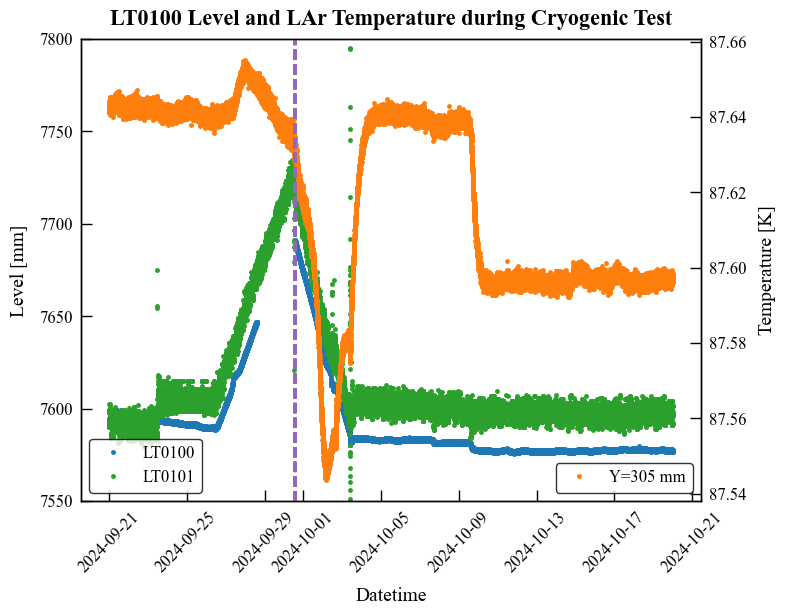

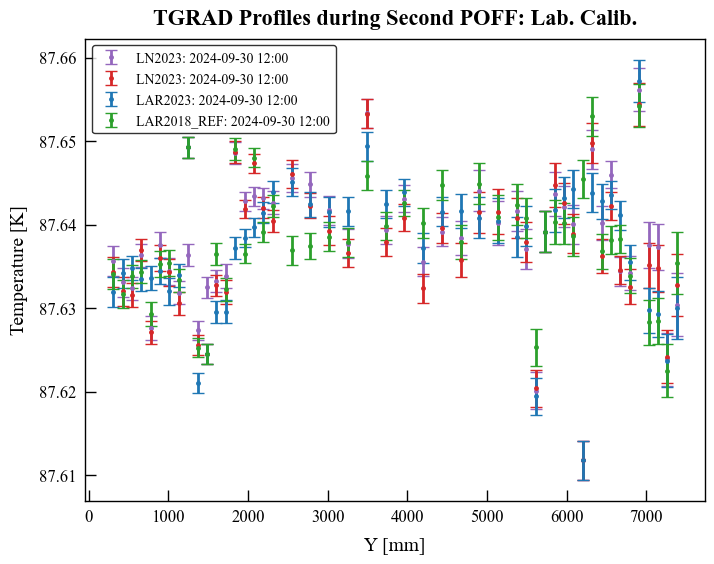

In [423]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.plot(level2.data.index, cryostat_height*level2.data.values/100, ".", label="LT0101", color="tab:green")
axes.legend(loc="lower left")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes.set_ylim(7550, 7800)
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label=fr"Y={tgrad.sensors[39607].Y:.0f} mm", color="tab:orange")
axes2.legend(loc="lower right")
axes2.set_ylabel("Temperature [K]")
axes.set_title("LT0100 Level and LAr Temperature during Cryogenic Test")
axes.tick_params(axis='x', rotation=45)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
tgrad.calibrate(calibName="LN2023_TREE_AVG")
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
axes2.axvline(t4, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t4 + deltat, color="tab:purple", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt=".", label=f"LN2023: {t4.strftime('%Y-%m-%d %H:%M')}", color="tab:purple")
ln23_profiles = tgrad.profiles.set_index("Y")
tgrad.calibrate(calibName="LN2022_TREE_AVG")
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
axes2.axvline(t4, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t4 + deltat, color="tab:purple", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt=".", label=f"LN2023: {t4.strftime('%Y-%m-%d %H:%M')}", color="tab:red")
ln22_profiles = tgrad.profiles.set_index("Y")
tgrad.calibrate(calibName="LAR2023_TREE_AVG")
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
axes2.axvline(t4, color="tab:purple", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t4 + deltat, color="tab:purple", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt=".", label=f"LAR2023: {t4.strftime('%Y-%m-%d %H:%M')}", color="tab:blue")
lar23_profiles = tgrad.profiles.set_index("Y")
tgrad.calibrate(calibName="LAR2018_REF")
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
axes2.axvline(t4, color="tab:purple", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t4 + deltat, color="tab:purple", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt=".", label=f"LAR2018_REF: {t4.strftime('%Y-%m-%d %H:%M')}", color="tab:green")
lar18_profiles = tgrad.profiles.set_index("Y")

merged_profiles = ln23_profiles.join(
    ln22_profiles,
    lsuffix="_ln23",
    rsuffix="_ln22",
    how="inner"
).join(
    lar23_profiles,
    rsuffix="_lar23",
    how="inner"
).join(
    lar18_profiles,
    rsuffix="_lar18",
    how="inner"
)

axes.set_xlabel("Y [mm]")
axes.set_ylabel("Temperature [K]")
axes.set_title("TGRAD Profiles during Second POFF: Lab. Calib.")
axes.legend(loc="best", ncol=1, fontsize="small")

Text(0.5, 1.0, 'TGRAD during September Cryo. Test (Pumps-On): Average Calib.')

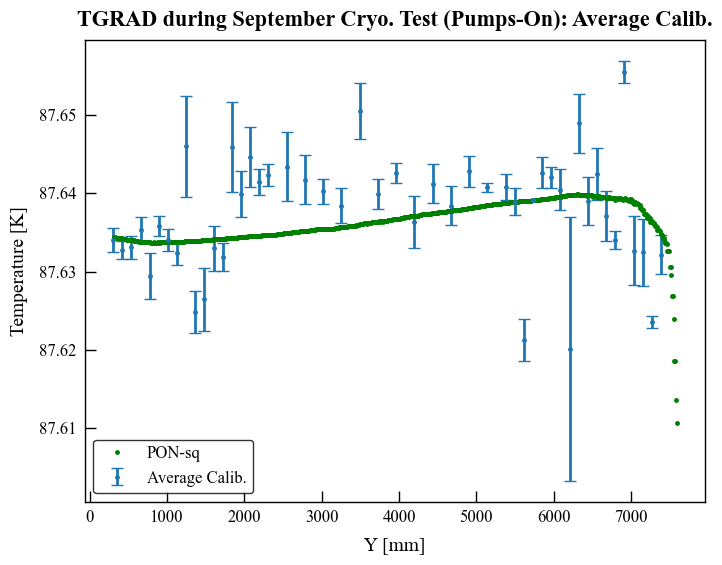

In [424]:
avg_temp = merged_profiles[["temp_ln22", "temp_ln23", "temp", "temp_lar18"]].mean(axis=1)
err_temp = merged_profiles[["temp_ln22", "temp_ln23", "temp", "temp_lar18"]].std(axis=1)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.errorbar(avg_temp.index, avg_temp.values, yerr=err_temp.values, fmt=".", label="Average Calib.", color="tab:blue")
cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes.plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd_poff.index>300)]["temp"].values + 0.040, '.', label=fr'PON-sq', color="green")
# axes.plot(1e3*cfd_poff.loc[(1e3*cfd_poff.index>300)].index.values, cfd_poff.loc[(1e3*cfd_poff.index>300)]["temp"].values + 0.053, '.', label=fr'POFF-sq', color="darkgreen")
axes.legend(loc="best", ncol=1)
axes.set_xlabel("Y [mm]")
axes.set_ylabel("Temperature [K]")
axes.set_title("TGRAD during September Cryo. Test (Pumps-On): Average Calib.")

MUX1: t3-t1: 3.33 nA, t4-t1: -10.94 nA, t5-t1: 3.07 nA, t6-t1: 7.42 nA
MUX2: t3-t1: -11.49 nA, t4-t1: -19.95 nA, t5-t1: -9.88 nA, t6-t1: 2.49 nA
MUX3: t3-t1: 10.30 nA, t4-t1: -1.25 nA, t5-t1: 7.52 nA, t6-t1: 4.80 nA
MUX4: t3-t1: 120.10 nA, t4-t1: 106.76 nA, t5-t1: 68.76 nA, t6-t1: -27.99 nA


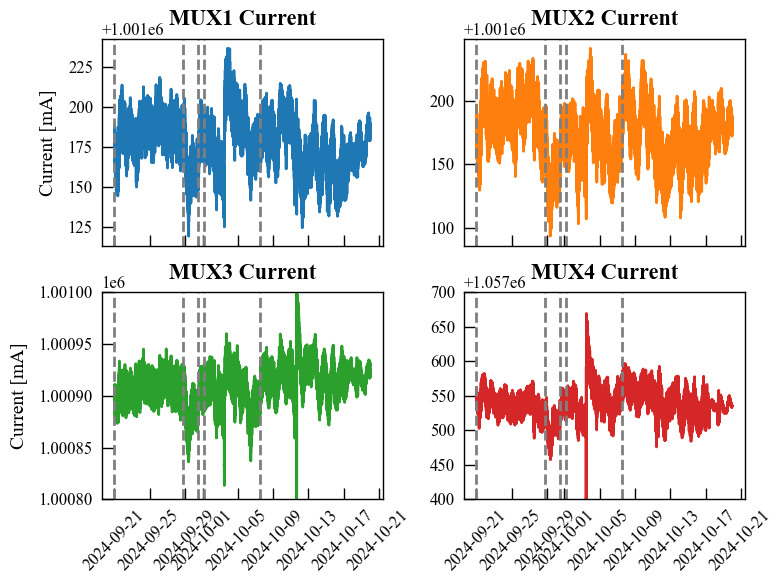

In [425]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
axes = axes.flatten()
axes[2].tick_params(axis='x', rotation=45)
axes[3].tick_params(axis='x', rotation=45)
axes[0].plot(mux1.data.index.values, 1e6*mux1.data.values, label=f"MUX1", color="tab:blue")
axes[1].plot(mux2.data.index.values, 1e6*mux2.data.values, label=f"MUX2", color="tab:orange")
axes[2].plot(mux3.data.index.values, 1e6*mux3.data.values, label=f"MUX3", color="tab:green")
axes[3].plot(mux4.data.index.values, 1e6*4.26/mux4.data.values, label=f"MUX4", color="tab:red")
axes[0].set_ylabel("Current [mA]")
axes[2].set_ylabel("Current [mA]")

axes[0].set_title("MUX1 Current")
axes[1].set_title("MUX2 Current")
axes[2].set_title("MUX3 Current")
axes[3].set_title("MUX4 Current")

mux1_t1 = mux1.data.loc[(mux1.data.index >= t1) & (mux1.data.index < t1 + deltat)].mean()
mux2_t1 = mux2.data.loc[(mux2.data.index >= t1) & (mux2.data.index < t1 + deltat)].mean()
mux3_t1 = mux3.data.loc[(mux3.data.index >= t1) & (mux3.data.index < t1 + deltat)].mean()
mux4_t1 = mux4.data.loc[(mux4.data.index >= t1) & (mux4.data.index < t1 + deltat)].mean()

axes[0].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")

mux1_t3 = mux1.data.loc[(mux1.data.index >= t3) & (mux1.data.index < t3 + deltat)].mean()
mux2_t3 = mux2.data.loc[(mux2.data.index >= t3) & (mux2.data.index < t3 + deltat)].mean()
mux3_t3 = mux3.data.loc[(mux3.data.index >= t3) & (mux3.data.index < t3 + deltat)].mean()
mux4_t3 = mux4.data.loc[(mux4.data.index >= t3) & (mux4.data.index < t3 + deltat)].mean()

axes[0].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")

mux1_t4 = mux1.data.loc[(mux1.data.index >= t4) & (mux1.data.index < t4 + deltat)].mean()
mux2_t4 = mux2.data.loc[(mux2.data.index >= t4) & (mux2.data.index < t4 + deltat)].mean()
mux3_t4 = mux3.data.loc[(mux3.data.index >= t4) & (mux3.data.index < t4 + deltat)].mean()
mux4_t4 = mux4.data.loc[(mux4.data.index >= t4) & (mux4.data.index < t4 + deltat)].mean()

axes[0].axvline(t4, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t4, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t4, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t4, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")

mux1_t5 = mux1.data.loc[(mux1.data.index >= t5) & (mux1.data.index < t5 + deltat)].mean()
mux2_t5 = mux2.data.loc[(mux2.data.index >= t5) & (mux2.data.index < t5 + deltat)].mean()
mux3_t5 = mux3.data.loc[(mux3.data.index >= t5) & (mux3.data.index < t5 + deltat)].mean()
mux4_t5 = mux4.data.loc[(mux4.data.index >= t5) & (mux4.data.index < t5 + deltat)].mean()

axes[0].axvline(t5, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t5, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t5, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t5, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")

mux1_t6 = mux1.data.loc[(mux1.data.index >= t6) & (mux1.data.index < t6 + deltat)].mean()
mux2_t6 = mux2.data.loc[(mux2.data.index >= t6) & (mux2.data.index < t6 + deltat)].mean()
mux3_t6 = mux3.data.loc[(mux3.data.index >= t6) & (mux3.data.index < t6 + deltat)].mean()
mux4_t6 = mux4.data.loc[(mux4.data.index >= t6) & (mux4.data.index < t6 + deltat)].mean()

axes[0].axvline(t6, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t6, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t6, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t6, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")

print(f"MUX1: t3-t1: {1e6*(mux1_t3-mux1_t1):.2f} nA, t4-t1: {1e6*(mux1_t4-mux1_t1):.2f} nA, t5-t1: {1e6*(mux1_t5-mux1_t1):.2f} nA, t6-t1: {1e6*(mux1_t6-mux1_t1):.2f} nA")
print(f"MUX2: t3-t1: {1e6*(mux2_t3-mux2_t1):.2f} nA, t4-t1: {1e6*(mux2_t4-mux2_t1):.2f} nA, t5-t1: {1e6*(mux2_t5-mux2_t1):.2f} nA, t6-t1: {1e6*(mux2_t6-mux2_t1):.2f} nA")
print(f"MUX3: t3-t1: {1e6*(mux3_t3-mux3_t1):.2f} nA, t4-t1: {1e6*(mux3_t4-mux3_t1):.2f} nA, t5-t1: {1e6*(mux3_t5-mux3_t1):.2f} nA, t6-t1: {1e6*(mux3_t6-mux3_t1):.2f} nA")
print(f"MUX4: t3-t1: {1e6*(mux4_t3-mux4_t1):.2f} nA, t4-t1: {1e6*(mux4_t4-mux4_t1):.2f} nA, t5-t1: {1e6*(mux4_t5-mux4_t1):.2f} nA, t6-t1: {1e6*(mux4_t6-mux4_t1):.2f} nA")

axes[2].set_ylim(1.0008e6, 1.001e6)
axes[3].set_ylim(1.0574e6, 1.0577e6)
fig.tight_layout()

(0.19, 0.23)

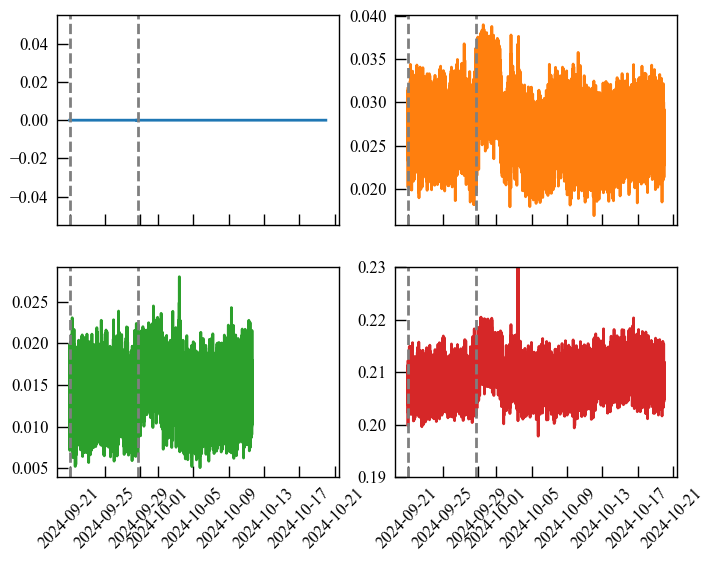

In [426]:
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39644)
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39607)
sensor3 = sensorClasses.Sensor(dataset=dataset, id=40002)
sensor4 = sensorClasses.Sensor(dataset=dataset, id=37127)

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
axes = axes.flatten()
axes[2].tick_params(axis='x', rotation=45)
axes[3].tick_params(axis='x', rotation=45)
axes[0].plot(sensor1.data.index.values, (sensor1.data-sensor1.data).values, label=f"Sensor 39644", color="tab:blue")
axes[1].plot(sensor2.data.index.values, (sensor2.data-sensor1.data).values, label=f"Sensor 39607", color="tab:orange")
axes[2].plot((sensor3.data-sensor1.data).index.values, (sensor3.data-sensor1.data).values, label=f"Sensor 44125", color="tab:green")
axes[3].plot((sensor4.data-sensor1.data).index.values, (sensor4.data-sensor1.data).values, label=f"Sensor 37127", color="tab:red")

axes[0].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")

axes[0].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")

axes[3].set_ylim(0.19, 0.23)


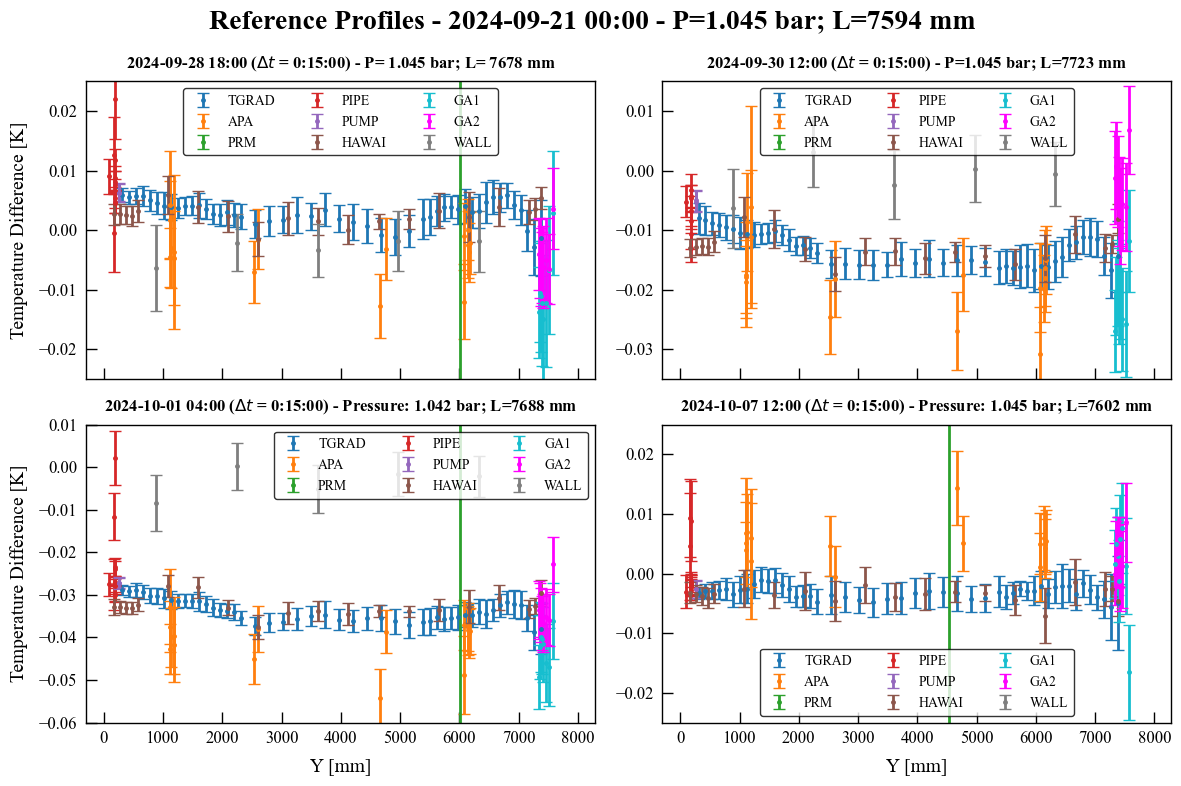

In [427]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = axes.flatten()
deltat = datetime.timedelta(minutes=15)
# t1 = datetime.datetime(2024, 5, 13, 9)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
ref_tgrad_profile = tgrad.profiles
apa.makeProfiles(tini=t1, tend=t1 + deltat)
ref_apa_profile = apa.profiles
prm.makeProfiles(tini=t1, tend=t1 + deltat)
ref_prm_profile = prm.profiles
pipe.makeProfiles(tini=t1, tend=t1 + deltat)
ref_pipe_profile = pipe.profiles
pump.makeProfiles(tini=t1, tend=t1 + deltat)
ref_pump_profile = pump.profiles
hawai.makeProfiles(tini=t1, tend=t1 + deltat)
ref_hawai_profile = hawai.profiles
ga1.makeProfiles(tini=t1, tend=t1 + deltat)
ref_ga1_profile = ga1.profiles
ga2.makeProfiles(tini=t1, tend=t1 + deltat)
ref_ga2_profile = ga2.profiles
wall.makeProfiles(tini=t1, tend=t1 + deltat)
ref_wall_profile = wall.profiles

# t3 = datetime.datetime(2024, 5, 15, 9)
tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
current_tgrad_profile = tgrad.profiles
axes[0].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]-ref_tgrad_profile["temp"]).values  , yerr=np.sqrt(current_tgrad_profile["err"].values**2 + ref_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t3, tend=t3 + deltat)
current_apa_profile = apa.profiles
axes[0].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]-ref_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2 + ref_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t3, tend=t3 + deltat)
current_prm_profile = prm.profiles
axes[0].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]-ref_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2 + ref_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t3, tend=t3 + deltat)
current_pipe_profile = pipe.profiles
axes[0].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]-ref_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2 + ref_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red")
pump.makeProfiles(tini=t3, tend=t3 + deltat)
current_pump_profile = pump.profiles
axes[0].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]-ref_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2 + ref_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple")
hawai.makeProfiles(tini=t3, tend=t3 + deltat)
current_hawai_profile = hawai.profiles
axes[0].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]-ref_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2 + ref_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t3, tend=t3 + deltat)
current_ga1_profile = ga1.profiles
axes[0].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]-ref_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2 + ref_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t3, tend=t3 + deltat)
current_ga2_profile = ga2.profiles
axes[0].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]-ref_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2 + ref_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t3, tend=t3 + deltat)
current_wall_profile = wall.profiles
axes[0].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]-ref_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2 + ref_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")

# t4 = datetime.datetime(2024, 5, 16, 9)
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
current_tgrad_profile = tgrad.profiles
axes[1].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]-ref_tgrad_profile["temp"]).values , yerr=np.sqrt(current_tgrad_profile["err"].values**2 + ref_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t4, tend=t4 + deltat)
current_apa_profile = apa.profiles
axes[1].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]-ref_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2 + ref_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t4, tend=t4 + deltat)
current_prm_profile = prm.profiles
axes[1].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]-ref_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2 + ref_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t4, tend=t4 + deltat)
current_pipe_profile = pipe.profiles
axes[1].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]-ref_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2 + ref_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red");
pump.makeProfiles(tini=t4, tend=t4 + deltat)
current_pump_profile = pump.profiles
axes[1].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]-ref_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2 + ref_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple");
hawai.makeProfiles(tini=t4, tend=t4 + deltat)
current_hawai_profile = hawai.profiles
axes[1].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]-ref_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2 + ref_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t4, tend=t4 + deltat)
current_ga1_profile = ga1.profiles
axes[1].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]-ref_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2 + ref_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t4, tend=t4 + deltat)
current_ga2_profile = ga2.profiles
axes[1].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]-ref_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2 + ref_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t4, tend=t4 + deltat)
current_wall_profile = wall.profiles
axes[1].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]-ref_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2 + ref_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")

# t5 = datetime.datetime(2024, 5, 17, 12)
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
current_tgrad_profile = tgrad.profiles
axes[2].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]-ref_tgrad_profile["temp"]).values , yerr=np.sqrt(current_tgrad_profile["err"].values**2 + ref_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t5, tend=t5 + deltat)
current_apa_profile = apa.profiles
axes[2].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]-ref_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2 + ref_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t5, tend=t5 + deltat)
current_prm_profile = prm.profiles
axes[2].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]-ref_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2 + ref_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t5, tend=t5 + deltat)
current_pipe_profile = pipe.profiles
axes[2].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]-ref_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2 + ref_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red")
pump.makeProfiles(tini=t5, tend=t5 + deltat)
current_pump_profile = pump.profiles
axes[2].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]-ref_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2 + ref_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple");
hawai.makeProfiles(tini=t5, tend=t5 + deltat)
current_hawai_profile = hawai.profiles
axes[2].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]-ref_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2 + ref_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t5, tend=t5 + deltat)
current_ga1_profile = ga1.profiles
axes[2].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]-ref_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2 + ref_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t5, tend=t5 + deltat)
current_ga2_profile = ga2.profiles
axes[2].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]-ref_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2 + ref_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t5, tend=t5 + deltat)
current_wall_profile = wall.profiles
axes[2].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]-ref_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2 + ref_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")

# t6 = datetime.datetime(2024, 5, 19, 12)
tgrad.makeProfiles(tini=t6, tend=t6 + deltat)
current_tgrad_profile = tgrad.profiles
axes[3].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]-ref_tgrad_profile["temp"]).values , yerr=np.sqrt(current_tgrad_profile["err"].values**2 + ref_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t6, tend=t6 + deltat)
current_apa_profile = apa.profiles
axes[3].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]-ref_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2 + ref_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t6, tend=t6 + deltat)
current_prm_profile = prm.profiles
axes[3].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]-ref_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2 + ref_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t6, tend=t6 + deltat)
current_pipe_profile = pipe.profiles
axes[3].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]-ref_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2 + ref_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red")
pump.makeProfiles(tini=t6, tend=t6 + deltat)
current_pump_profile = pump.profiles
axes[3].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]-ref_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2 + ref_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple");
hawai.makeProfiles(tini=t6, tend=t6 + deltat)
current_hawai_profile = hawai.profiles
axes[3].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]-ref_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2 + ref_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t6, tend=t6 + deltat)
current_ga1_profile = ga1.profiles
axes[3].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]-ref_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2 + ref_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t6, tend=t6 + deltat)
current_ga2_profile = ga2.profiles
axes[3].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]-ref_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2 + ref_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t6, tend=t6 + deltat)
current_wall_profile = wall.profiles
axes[3].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]-ref_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2 + ref_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")

p1 = pressure1.data.loc[(pressure1.data.index >= t1) & (pressure1.data.index < t1 + deltat)].mean()
p3 = pressure1.data.loc[(pressure1.data.index >= t3) & (pressure1.data.index < t3 + deltat)].mean()
p4 = pressure1.data.loc[(pressure1.data.index >= t4) & (pressure1.data.index < t4 + deltat)].mean()
p5 = pressure1.data.loc[(pressure1.data.index >= t5) & (pressure1.data.index < t5 + deltat)].mean()
p6 = pressure1.data.loc[(pressure1.data.index >= t6) & (pressure1.data.index < t6 + deltat)].mean()

l1 = cryostat_height*level2.data.loc[(level1.data.index >= t1) & (level1.data.index < t1 + deltat)].mean()/100
l3 = cryostat_height*level2.data.loc[(level1.data.index >= t3) & (level1.data.index < t3 + deltat)].mean()/100
l4 = cryostat_height*level2.data.loc[(level1.data.index >= t4) & (level1.data.index < t4 + deltat)].mean()/100
l5 = cryostat_height*level2.data.loc[(level1.data.index >= t5) & (level1.data.index < t5 + deltat)].mean()/100
l6 = cryostat_height*level2.data.loc[(level1.data.index >= t6) & (level1.data.index < t6 + deltat)].mean()/100

# axes[0].set_ylim(-0.025, 0.025)
axes[0].set_ylim(-0.025, 0.025)
axes[1].set_ylim(-0.035, 0.015)
axes[2].set_ylim(-0.06, 0.01)
axes[3].set_ylim(-0.025, 0.025)
# axes[0].set_xlabel("Y [mm]")
axes[0].set_ylabel("Temperature Difference [K]")
axes[0].set_title(fr"{t3.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - P= {p3:.3f} bar; L= {l3:.0f} mm", fontsize=12)
axes[0].legend(loc="upper center", fontsize="small", ncol=3)

axes[1].legend(loc="best", fontsize="small", ncol=3)
axes[1].set_title(fr"{t4.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - P={p4:.3f} bar; L={l4:.0f} mm", fontsize=12)

axes[2].set_xlabel("Y [mm]")
axes[2].set_ylabel("Temperature Difference [K]")
axes[2].set_title(fr"{t5.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - Pressure: {p5:.3f} bar; L={l5:.0f} mm", fontsize=12)
axes[2].legend(loc="best", fontsize="small", ncol=3)

axes[3].set_xlabel("Y [mm]")
axes[3].set_title(fr"{t6.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - Pressure: {p6:.3f} bar; L={l6:.0f} mm", fontsize=12)
axes[3].legend(loc="best", fontsize="small", ncol=3)

fig.suptitle(fr"Reference Profiles - {t1.strftime('%Y-%m-%d %H:%M')} - P={p1:.3f} bar; L={l1:.0f} mm", fontsize=20, fontweight="bold")
fig.tight_layout()

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:06<00:00,  7.57sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 48/48 [00:00<00:00, 91.61sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00,  9.14sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 24/24 [00:00<00:00, 73.53sensor/s]


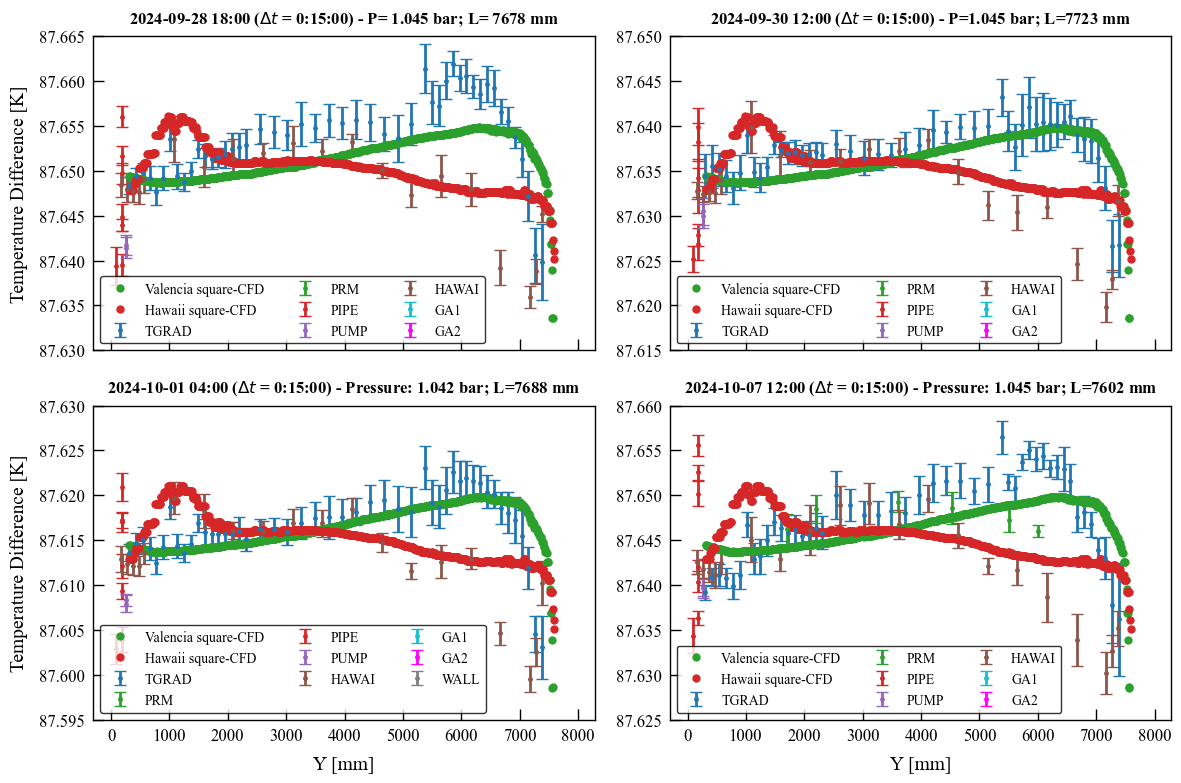

In [483]:
tgrad.calibrate(calibName="SECOND_POFF_EMPTY")
hawai.calibrate(calibName="SECOND_POFF_EMPTY")

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = axes.flatten()
deltat = datetime.timedelta(minutes=15)
# t1 = datetime.datetime(2024, 5, 13, 9)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
ref_tgrad_profile = tgrad.profiles
apa.makeProfiles(tini=t1, tend=t1 + deltat)
ref_apa_profile = apa.profiles
prm.makeProfiles(tini=t1, tend=t1 + deltat)
ref_prm_profile = prm.profiles
pipe.makeProfiles(tini=t1, tend=t1 + deltat)
ref_pipe_profile = pipe.profiles
pump.makeProfiles(tini=t1, tend=t1 + deltat)
ref_pump_profile = pump.profiles
hawai.makeProfiles(tini=t1, tend=t1 + deltat)
ref_hawai_profile = hawai.profiles
ga1.makeProfiles(tini=t1, tend=t1 + deltat)
ref_ga1_profile = ga1.profiles
ga2.makeProfiles(tini=t1, tend=t1 + deltat)
ref_ga2_profile = ga2.profiles
wall.makeProfiles(tini=t1, tend=t1 + deltat)
ref_wall_profile = wall.profiles

# t3 = datetime.datetime(2024, 5, 15, 9)
tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
current_tgrad_profile = tgrad.profiles
axes[0].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]).values  , yerr=np.sqrt(current_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t3, tend=t3 + deltat)
current_apa_profile = apa.profiles
# axes[0].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t3, tend=t3 + deltat)
current_prm_profile = prm.profiles
axes[0].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t3, tend=t3 + deltat)
current_pipe_profile = pipe.profiles
axes[0].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red")
pump.makeProfiles(tini=t3, tend=t3 + deltat)
current_pump_profile = pump.profiles
axes[0].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple")
hawai.makeProfiles(tini=t3, tend=t3 + deltat)
current_hawai_profile = hawai.profiles
axes[0].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t3, tend=t3 + deltat)
current_ga1_profile = ga1.profiles
axes[0].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t3, tend=t3 + deltat)
current_ga2_profile = ga2.profiles
axes[0].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t3, tend=t3 + deltat)
current_wall_profile = wall.profiles
# axes[0].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[0].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values + 0.055, 'o', label=fr'Valencia square-CFD', color="tab:green")
cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[0].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, (cfd.loc[(1e3*cfd.index>300)]["temp"] - cfd_poff.loc[(1e3*cfd.index>300)]["temp"] + cfd_poff.loc[(1e3*cfd.index>300)]["temp"].mean()).values + 0.055, 'o', label=fr'Hawaii square-CFD', color="tab:red")

# t4 = datetime.datetime(2024, 5, 16, 9)
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
current_tgrad_profile = tgrad.profiles
current_tgrad_profile.to_csv("/Users/jcapo/cernbox/DUNE-IFIC/Experiments/ProtoDUNE-HD/Operation/Data/tgrad_high-lar-CE-ON-REC-ON_cal-poff_empty.csv", header=True, index=True)
axes[1].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]).values , yerr=np.sqrt(current_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t4, tend=t4 + deltat)
current_apa_profile = apa.profiles
# axes[1].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t4, tend=t4 + deltat)
current_prm_profile = prm.profiles
axes[1].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t4, tend=t4 + deltat)
current_pipe_profile = pipe.profiles
axes[1].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red");
pump.makeProfiles(tini=t4, tend=t4 + deltat)
current_pump_profile = pump.profiles
axes[1].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple");
hawai.makeProfiles(tini=t4, tend=t4 + deltat)
current_hawai_profile = hawai.profiles
current_hawai_profile.to_csv("/Users/jcapo/cernbox/DUNE-IFIC/Experiments/ProtoDUNE-HD/Operation/Data/hawai_high-lar-CE-ON-REC-ON_cal-poff_empty.csv", header=True, index=True)
axes[1].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t4, tend=t4 + deltat)
current_ga1_profile = ga1.profiles
axes[1].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t4, tend=t4 + deltat)
current_ga2_profile = ga2.profiles
axes[1].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t4, tend=t4 + deltat)
current_wall_profile = wall.profiles
# axes[1].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[1].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values + 0.040, 'o', label=fr'Valencia square-CFD', color="tab:green")
cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[1].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, (cfd.loc[(1e3*cfd.index>300)]["temp"] - cfd_poff.loc[(1e3*cfd.index>300)]["temp"] + cfd_poff.loc[(1e3*cfd.index>300)]["temp"].mean()).values + 0.040, 'o', label=fr'Hawaii square-CFD', color="tab:red")

# t5 = datetime.datetime(2024, 5, 17, 12)
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
current_tgrad_profile = tgrad.profiles
axes[2].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]).values , yerr=np.sqrt(current_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t5, tend=t5 + deltat)
current_apa_profile = apa.profiles
# axes[2].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t5, tend=t5 + deltat)
current_prm_profile = prm.profiles
axes[2].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t5, tend=t5 + deltat)
current_pipe_profile = pipe.profiles
axes[2].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red")
pump.makeProfiles(tini=t5, tend=t5 + deltat)
current_pump_profile = pump.profiles
axes[2].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple");
hawai.makeProfiles(tini=t5, tend=t5 + deltat)
current_hawai_profile = hawai.profiles
axes[2].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t5, tend=t5 + deltat)
current_ga1_profile = ga1.profiles
axes[2].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t5, tend=t5 + deltat)
current_ga2_profile = ga2.profiles
axes[2].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t5, tend=t5 + deltat)
current_wall_profile = wall.profiles
axes[2].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[2].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values + 0.020, 'o', label=fr'Valencia square-CFD', color="tab:green")
cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[2].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, (cfd.loc[(1e3*cfd.index>300)]["temp"] - cfd_poff.loc[(1e3*cfd.index>300)]["temp"] + cfd_poff.loc[(1e3*cfd.index>300)]["temp"].mean()).values + 0.020, 'o', label=fr'Hawaii square-CFD', color="tab:red")

# t6 = datetime.datetime(2024, 5, 19, 12)
tgrad.makeProfiles(tini=t6, tend=t6 + deltat)
current_tgrad_profile = tgrad.profiles
current_tgrad_profile.to_csv("/Users/jcapo/cernbox/DUNE-IFIC/Experiments/ProtoDUNE-HD/Operation/Data/tgrad_nominal-lar-CE-ON-REC-ON_cal-poff_empty.csv", header=True, index=True)
axes[3].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]).values , yerr=np.sqrt(current_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t6, tend=t6 + deltat)
current_apa_profile = apa.profiles
# axes[3].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t6, tend=t6 + deltat)
current_prm_profile = prm.profiles
axes[3].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]).values + 0.007, yerr=np.sqrt(current_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t6, tend=t6 + deltat)
current_pipe_profile = pipe.profiles
axes[3].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]).values + 0.007, yerr=np.sqrt(current_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red")
pump.makeProfiles(tini=t6, tend=t6 + deltat)
current_pump_profile = pump.profiles
axes[3].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]).values + 0.007, yerr=np.sqrt(current_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple");
hawai.makeProfiles(tini=t6, tend=t6 + deltat)
current_hawai_profile = hawai.profiles
current_hawai_profile.to_csv("/Users/jcapo/cernbox/DUNE-IFIC/Experiments/ProtoDUNE-HD/Operation/Data/hawai_nominal-lar-CE-ON-REC-ON_cal-poff_empty.csv", header=True, index=True)
axes[3].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t6, tend=t6 + deltat)
current_ga1_profile = ga1.profiles
axes[3].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t6, tend=t6 + deltat)
current_ga2_profile = ga2.profiles
axes[3].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t6, tend=t6 + deltat)
current_wall_profile = wall.profiles
# axes[3].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[3].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values + 0.050, 'o', label=fr'Valencia square-CFD', color="tab:green")
cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[3].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, (cfd.loc[(1e3*cfd.index>300)]["temp"] - cfd_poff.loc[(1e3*cfd.index>300)]["temp"] + cfd_poff.loc[(1e3*cfd.index>300)]["temp"].mean()).values + 0.050, 'o', label=fr'Hawaii square-CFD', color="tab:red")

p1 = pressure1.data.loc[(pressure1.data.index >= t1) & (pressure1.data.index < t1 + deltat)].mean()
p3 = pressure1.data.loc[(pressure1.data.index >= t3) & (pressure1.data.index < t3 + deltat)].mean()
p4 = pressure1.data.loc[(pressure1.data.index >= t4) & (pressure1.data.index < t4 + deltat)].mean()
p5 = pressure1.data.loc[(pressure1.data.index >= t5) & (pressure1.data.index < t5 + deltat)].mean()
p6 = pressure1.data.loc[(pressure1.data.index >= t6) & (pressure1.data.index < t6 + deltat)].mean()

l1 = cryostat_height*level2.data.loc[(level1.data.index >= t1) & (level1.data.index < t1 + deltat)].mean()/100
l3 = cryostat_height*level2.data.loc[(level1.data.index >= t3) & (level1.data.index < t3 + deltat)].mean()/100
l4 = cryostat_height*level2.data.loc[(level1.data.index >= t4) & (level1.data.index < t4 + deltat)].mean()/100
l5 = cryostat_height*level2.data.loc[(level1.data.index >= t5) & (level1.data.index < t5 + deltat)].mean()/100
l6 = cryostat_height*level2.data.loc[(level1.data.index >= t6) & (level1.data.index < t6 + deltat)].mean()/100

# axes[0].set_ylim(-0.025, 0.025)
axes[0].set_ylim(87.63, 87.665)
axes[1].set_ylim(87.615, 87.65)
axes[2].set_ylim(87.595, 87.63)
axes[3].set_ylim(87.625, 87.66)
# axes[0].set_xlabel("Y [mm]")
axes[0].set_ylabel("Temperature Difference [K]")
axes[0].set_title(fr"{t3.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - P= {p3:.3f} bar; L= {l3:.0f} mm", fontsize=12)
axes[0].legend(loc="best", fontsize="small", ncol=3)

axes[1].legend(loc="best", fontsize="small", ncol=3)
axes[1].set_title(fr"{t4.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - P={p4:.3f} bar; L={l4:.0f} mm", fontsize=12)

axes[2].set_xlabel("Y [mm]")
axes[2].set_ylabel("Temperature Difference [K]")
axes[2].set_title(fr"{t5.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - Pressure: {p5:.3f} bar; L={l5:.0f} mm", fontsize=12)
axes[2].legend(loc="best", fontsize="small", ncol=3)

axes[3].set_xlabel("Y [mm]")
axes[3].set_title(fr"{t6.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - Pressure: {p6:.3f} bar; L={l6:.0f} mm", fontsize=12)
axes[3].legend(loc="best", fontsize="small", ncol=3)

# fig.suptitle(fr"Reference Profiles - {t1.strftime('%Y-%m-%d %H:%M')} - P={p1:.3f} bar; L={l1:.0f} mm", fontsize=20, fontweight="bold")
fig.tight_layout()

Equalizing GA-1 Sensors: 100%|██████████| 18/18 [00:02<00:00,  7.13sensor/s]
Calibrating GA-1 Sensors - Calibration Name: LN2023_GA_PM_PP: 100%|██████████| 18/18 [00:00<00:00, 86.90sensor/s]


ERROR: SensorID (1) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (2) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (3) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (4) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (5) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (6) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (7) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (8) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (9) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (10) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (11) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (12) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (13) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (14) not found in calibration (LN2023_GA_PM_PP)


Equalizing GA-2 Sensors: 100%|██████████| 18/18 [00:02<00:00,  8.34sensor/s]
Calibrating GA-2 Sensors - Calibration Name: LN2023_GA_PM_PP: 100%|██████████| 18/18 [00:00<00:00, 92.66sensor/s]


ERROR: SensorID (15) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (16) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (17) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (18) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (19) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (20) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (21) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (22) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (23) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (24) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (25) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (26) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (27) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (28) not found in calibration (LN2023_GA_PM_PP)


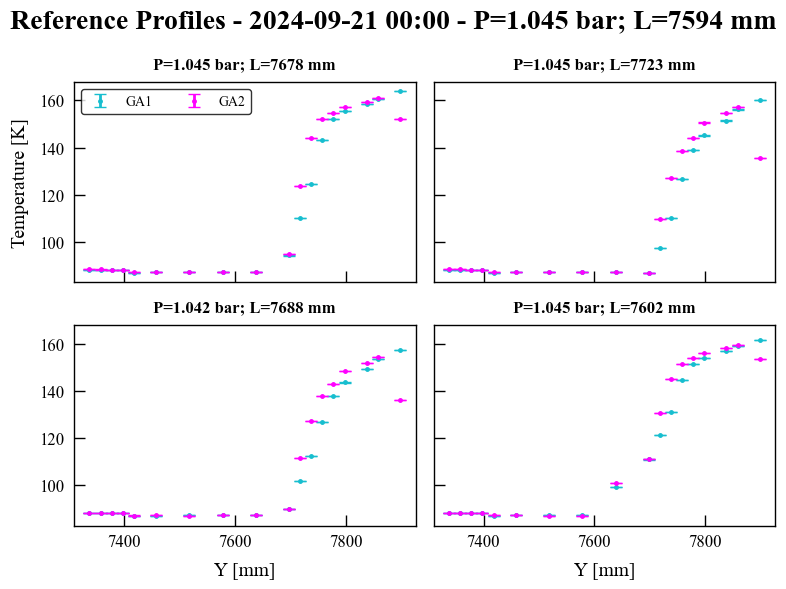

In [473]:
ga1.calibrate(calibName="LN2023_GA_PM_PP")
ga2.calibrate(calibName="LN2023_GA_PM_PP")
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)
axes = axes.flatten()
ga1.makeProfiles(tini=t3, tend=t3 + deltat)
ga2.makeProfiles(tini=t3, tend=t3 + deltat)
axes[0].errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=ga1.profiles["err"].values, fmt=".", label=f"GA1", color="tab:cyan")
axes[0].errorbar(ga2.profiles["Y"].values, ga2.profiles["temp"].values, yerr=ga2.profiles["err"].values, fmt=".", label=f"GA2", color="magenta")
ga1.makeProfiles(tini=t4, tend=t4 + deltat)
ga2.makeProfiles(tini=t4, tend=t4 + deltat)
axes[1].errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=ga1.profiles["err"].values, fmt=".", label=f"GA1", color="tab:cyan")
axes[1].errorbar(ga2.profiles["Y"].values, ga2.profiles["temp"].values, yerr=ga2.profiles["err"].values, fmt=".", label=f"GA2", color="magenta")
ga1.makeProfiles(tini=t5, tend=t5 + deltat)
ga2.makeProfiles(tini=t5, tend=t5 + deltat)
axes[2].errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=ga1.profiles["err"].values, fmt=".", label=f"GA1", color="tab:cyan")
axes[2].errorbar(ga2.profiles["Y"].values, ga2.profiles["temp"].values, yerr=ga2.profiles["err"].values, fmt=".", label=f"GA2", color="magenta")
ga1.makeProfiles(tini=t6, tend=t6 + deltat)
ga2.makeProfiles(tini=t6, tend=t6 + deltat)
axes[3].errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=ga1.profiles["err"].values, fmt=".", label=f"GA1", color="tab:cyan")
axes[3].errorbar(ga2.profiles["Y"].values, ga2.profiles["temp"].values, yerr=ga2.profiles["err"].values, fmt=".", label=f"GA2", color="magenta")
axes[0].set_ylabel("Temperature [K]")
axes[0].set_title(fr"P={p3:.3f} bar; L={l3:.0f} mm", fontsize=12)
axes[1].set_title(fr"P={p4:.3f} bar; L={l4:.0f} mm", fontsize=12)
axes[2].set_xlabel("Y [mm]")
axes[2].set_title(fr"P={p5:.3f} bar; L={l5:.0f} mm", fontsize=12)
axes[3].set_xlabel("Y [mm]")
axes[3].set_title(fr"P={p6:.3f} bar; L={l6:.0f} mm", fontsize=12)
fig.suptitle(fr"Reference Profiles - {t1.strftime('%Y-%m-%d %H:%M')} - P={p1:.3f} bar; L={l1:.0f} mm", fontsize=20, fontweight="bold")
axes[0].legend(loc="best", fontsize="small", ncol=3)
fig.tight_layout()

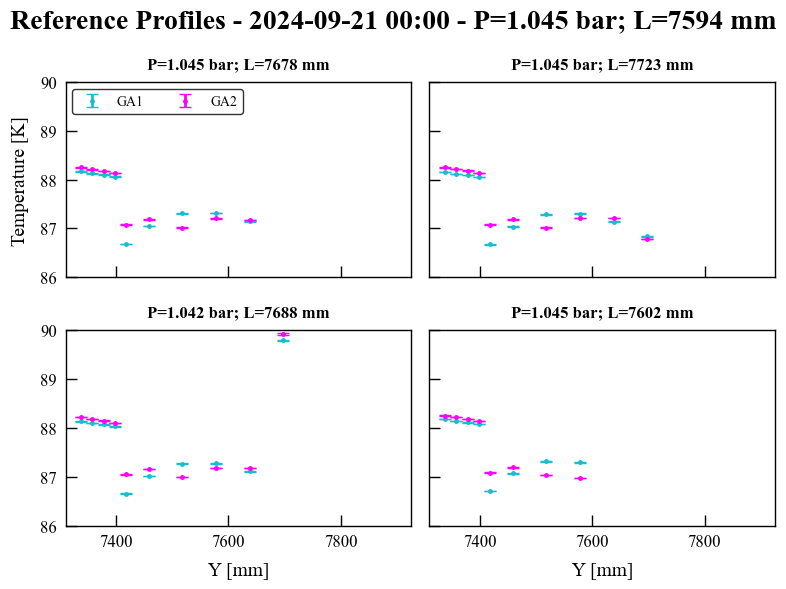

In [472]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)
axes = axes.flatten()
axes[0].set_ylim(86,90)
ga1.makeProfiles(tini=t3, tend=t3 + deltat)
ga2.makeProfiles(tini=t3, tend=t3 + deltat)
axes[0].errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=ga1.profiles["err"].values, fmt=".", label=f"GA1", color="tab:cyan")
axes[0].errorbar(ga2.profiles["Y"].values, ga2.profiles["temp"].values, yerr=ga2.profiles["err"].values, fmt=".", label=f"GA2", color="magenta")
ga1.makeProfiles(tini=t4, tend=t4 + deltat)
ga2.makeProfiles(tini=t4, tend=t4 + deltat)
axes[1].errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=ga1.profiles["err"].values, fmt=".", label=f"GA1", color="tab:cyan")
axes[1].errorbar(ga2.profiles["Y"].values, ga2.profiles["temp"].values, yerr=ga2.profiles["err"].values, fmt=".", label=f"GA2", color="magenta")
ga1.makeProfiles(tini=t5, tend=t5 + deltat)
ga2.makeProfiles(tini=t5, tend=t5 + deltat)
axes[2].errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=ga1.profiles["err"].values, fmt=".", label=f"GA1", color="tab:cyan")
axes[2].errorbar(ga2.profiles["Y"].values, ga2.profiles["temp"].values, yerr=ga2.profiles["err"].values, fmt=".", label=f"GA2", color="magenta")
ga1.makeProfiles(tini=t6, tend=t6 + deltat)
ga2.makeProfiles(tini=t6, tend=t6 + deltat)
axes[3].errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=ga1.profiles["err"].values, fmt=".", label=f"GA1", color="tab:cyan")
axes[3].errorbar(ga2.profiles["Y"].values, ga2.profiles["temp"].values, yerr=ga2.profiles["err"].values, fmt=".", label=f"GA2", color="magenta")
axes[0].set_ylabel("Temperature [K]")
axes[0].set_title(fr"P={p3:.3f} bar; L={l3:.0f} mm", fontsize=12)
axes[1].set_title(fr"P={p4:.3f} bar; L={l4:.0f} mm", fontsize=12)
axes[2].set_xlabel("Y [mm]")
axes[2].set_title(fr"P={p5:.3f} bar; L={l5:.0f} mm", fontsize=12)
axes[3].set_xlabel("Y [mm]")
axes[3].set_title(fr"P={p6:.3f} bar; L={l6:.0f} mm", fontsize=12)
fig.suptitle(fr"Reference Profiles - {t1.strftime('%Y-%m-%d %H:%M')} - P={p1:.3f} bar; L={l1:.0f} mm", fontsize=20, fontweight="bold")
axes[0].legend(loc="best", fontsize="small", ncol=3)
fig.tight_layout()

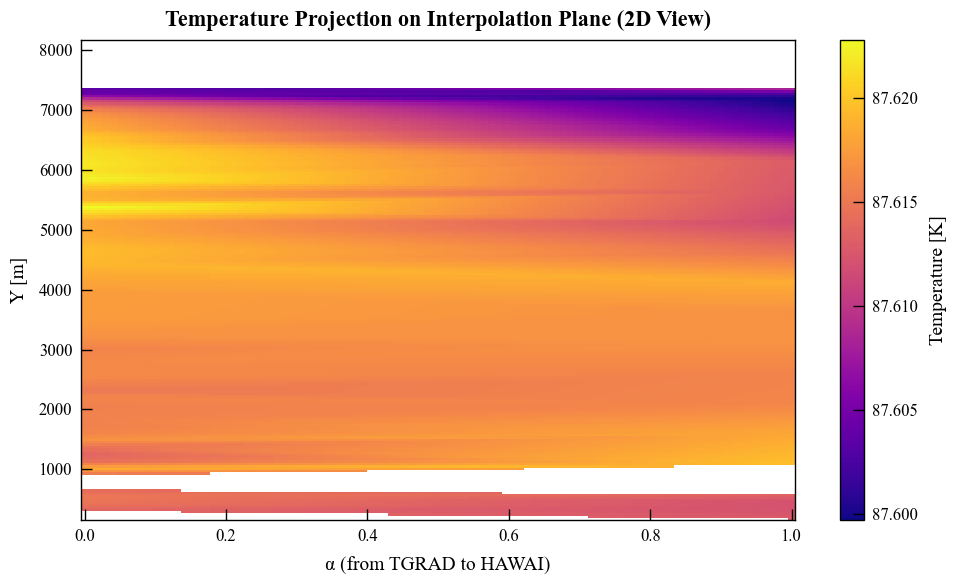

In [459]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# 1. Generate the profiles (Assuming these have been already done)
# tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
# hawai.makeProfiles(tini=t5, tend=t5 + deltat)

# Example of profile data (replace this with your actual profile data)
# Sample structure: X, Z, Y, Temp
# Replace these with your actual profile data
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
hawai.makeProfiles(tini=t5, tend=t5 + deltat)
tgrad_profile = tgrad.profiles.copy()  # Replace with your data
hawai_profile = hawai.profiles.copy()  # Replace with your data

# 2. Sensor positions
x_tgrad, z_tgrad = tgrad_profile["X"].unique()[0], tgrad_profile["Z"].unique()[0]
x_hawai, z_hawai = hawai_profile["X"].unique()[0], hawai_profile["Z"].unique()[0]

# 3. Combine all (Y, X, Z, Temp) points
def profile_to_xyz_temp(profile):
    return np.column_stack([
        profile["Y"].values,  # This will become Z
        profile["X"].values,
        profile["Z"].values,
        profile["temp"].values
    ])

data = np.vstack([
    profile_to_xyz_temp(tgrad_profile),
    profile_to_xyz_temp(hawai_profile)
])
Y_all, X_all, Z_all, Temp_all = data.T  # Y_all becomes the new vertical axis (Z)

# 4. Compute α (same as before)
def compute_alpha(x, z, x0, z0, x1, z1):
    vec = np.array([x1 - x0, z1 - z0])
    pos = np.array([x - x0, z - z0])
    alpha = np.dot(pos, vec) / np.dot(vec, vec)
    return alpha

alphas = np.array([
    compute_alpha(x, z, x_tgrad, z_tgrad, x_hawai, z_hawai)
    for x, z in zip(X_all, Z_all)
])

# 5. Interpolation grid in (Z, α)
z_grid = np.linspace(Y_all.min(), Y_all.max(), 200)  # Former Y becomes vertical Z
alpha_grid = np.linspace(0, 1, 100)
grid_Z, grid_alpha = np.meshgrid(z_grid, alpha_grid)

# 6. Interpolate temperature in (Z, α)
grid_temp = griddata(
    points=np.column_stack((Y_all, alphas)),  # Y_all is now vertical Z
    values=Temp_all,
    xi=(grid_Z, grid_alpha),
    method='linear'
)

# 7. Map to (X, Y, Z) with Z as vertical axis
grid_X = x_tgrad + grid_alpha * (x_hawai - x_tgrad)
grid_Y = z_tgrad + grid_alpha * (z_hawai - z_tgrad)  # horizontal Z axis now becomes Y
# grid_Z remains vertical (was Y)

# 8. Plot the 2D projection
fig, ax = plt.subplots(figsize=(10, 6))

# Plot heatmap: alpha (horizontal) vs Z (vertical)
c = ax.pcolormesh(grid_alpha, grid_Z, grid_temp, shading='auto', cmap='plasma')
cb = plt.colorbar(c, ax=ax, label="Temperature [K]")

ax.set_xlabel("α (from TGRAD to HAWAI)")
ax.set_ylabel("Y [m]")  # former Y
ax.set_title("Temperature Projection on Interpolation Plane (2D View)")

plt.tight_layout()
plt.show()


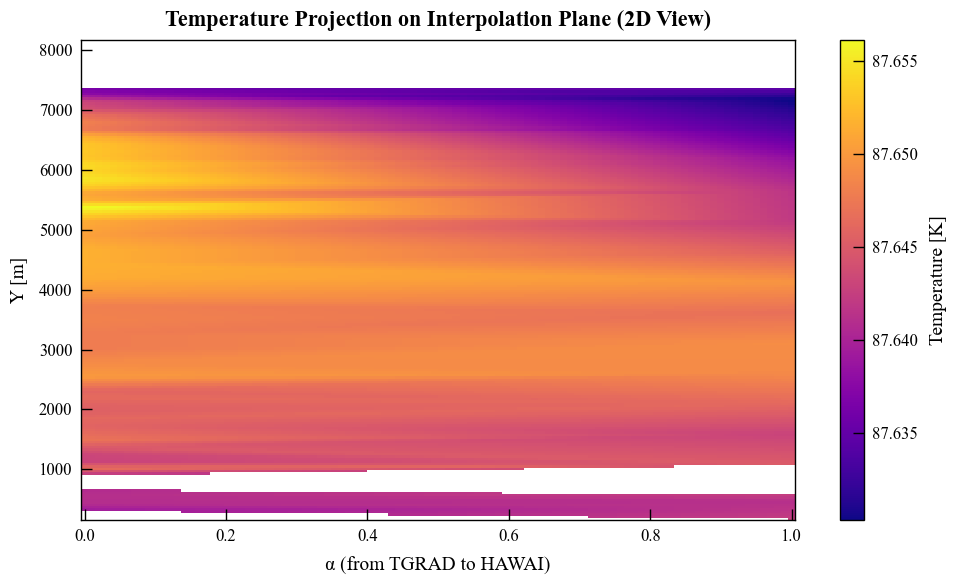

In [460]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# 1. Generate the profiles (Assuming these have been already done)
# tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
# hawai.makeProfiles(tini=t5, tend=t5 + deltat)

# Example of profile data (replace this with your actual profile data)
# Sample structure: X, Z, Y, Temp
# Replace these with your actual profile data
tgrad.makeProfiles(tini=t6, tend=t6 + deltat)
hawai.makeProfiles(tini=t6, tend=t6 + deltat)
tgrad_profile = tgrad.profiles.copy()  # Replace with your data
hawai_profile = hawai.profiles.copy()  # Replace with your data

# 2. Sensor positions
x_tgrad, z_tgrad = tgrad_profile["X"].unique()[0], tgrad_profile["Z"].unique()[0]
x_hawai, z_hawai = hawai_profile["X"].unique()[0], hawai_profile["Z"].unique()[0]

# 3. Combine all (Y, X, Z, Temp) points
def profile_to_xyz_temp(profile):
    return np.column_stack([
        profile["Y"].values,  # This will become Z
        profile["X"].values,
        profile["Z"].values,
        profile["temp"].values
    ])

data = np.vstack([
    profile_to_xyz_temp(tgrad_profile),
    profile_to_xyz_temp(hawai_profile)
])
Y_all, X_all, Z_all, Temp_all = data.T  # Y_all becomes the new vertical axis (Z)

# 4. Compute α (same as before)
def compute_alpha(x, z, x0, z0, x1, z1):
    vec = np.array([x1 - x0, z1 - z0])
    pos = np.array([x - x0, z - z0])
    alpha = np.dot(pos, vec) / np.dot(vec, vec)
    return alpha

alphas = np.array([
    compute_alpha(x, z, x_tgrad, z_tgrad, x_hawai, z_hawai)
    for x, z in zip(X_all, Z_all)
])

# 5. Interpolation grid in (Z, α)
z_grid = np.linspace(Y_all.min(), Y_all.max(), 200)  # Former Y becomes vertical Z
alpha_grid = np.linspace(0, 1, 100)
grid_Z, grid_alpha = np.meshgrid(z_grid, alpha_grid)

# 6. Interpolate temperature in (Z, α)
grid_temp = griddata(
    points=np.column_stack((Y_all, alphas)),  # Y_all is now vertical Z
    values=Temp_all,
    xi=(grid_Z, grid_alpha),
    method='linear'
)

# 7. Map to (X, Y, Z) with Z as vertical axis
grid_X = x_tgrad + grid_alpha * (x_hawai - x_tgrad)
grid_Y = z_tgrad + grid_alpha * (z_hawai - z_tgrad)  # horizontal Z axis now becomes Y
# grid_Z remains vertical (was Y)

# 8. Plot the 2D projection
fig, ax = plt.subplots(figsize=(10, 6))

# Plot heatmap: alpha (horizontal) vs Z (vertical)
c = ax.pcolormesh(grid_alpha, grid_Z, grid_temp, shading='auto', cmap='plasma')
cb = plt.colorbar(c, ax=ax, label="Temperature [K]")

ax.set_xlabel("α (from TGRAD to HAWAI)")
ax.set_ylabel("Y [m]")  # former Y
ax.set_title("Temperature Projection on Interpolation Plane (2D View)")

plt.tight_layout()
plt.show()


Initializing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 10.25sensor/s]


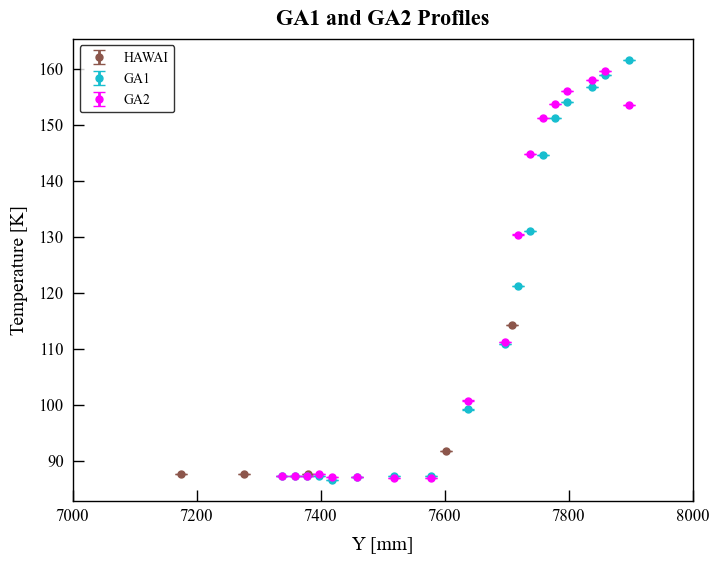

In [429]:
hawai = systemClasses.System(dataset=dataset, name="HAWAI")
hawai.makeProfiles(tini=t6, tend=t6 + deltat)
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=np.sqrt(hawai.profiles["err"].values**2), fmt="o", label="HAWAI", color="tab:brown")
axes.errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=np.sqrt(ga1.profiles["err"].values**2), fmt="o", label="GA1", color="tab:cyan")
axes.errorbar(ga2.profiles["Y"].values, ga2.profiles["temp"].values, yerr=np.sqrt(ga2.profiles["err"].values**2), fmt="o", label="GA2", color="magenta")
axes.set_xlim(7000,8000)
axes.set_xlabel("Y [mm]")
axes.set_ylabel("Temperature [K]")
axes.set_title("GA1 and GA2 Profiles")
axes.legend(loc="best", fontsize="small")

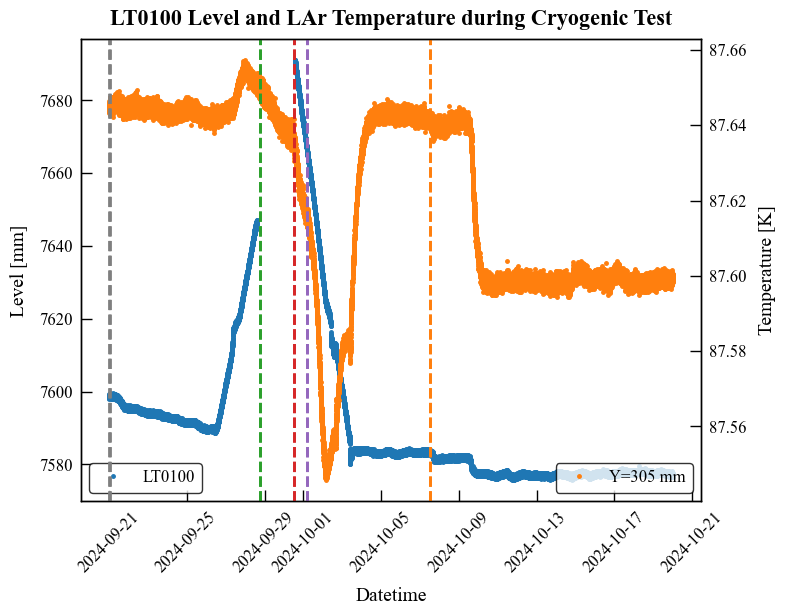

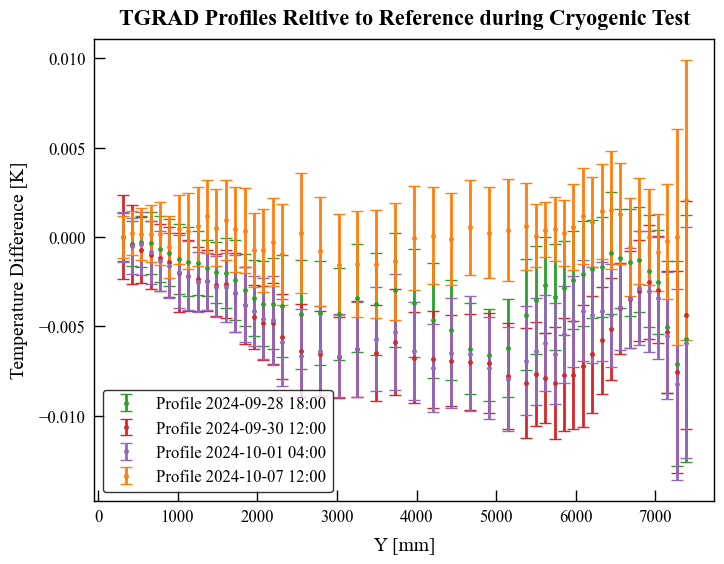

In [131]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.legend(loc="lower left")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label=fr"Y={tgrad.sensors[39607].Y:.0f} mm", color="tab:orange")
axes2.legend(loc="lower right")
axes2.set_ylabel("Temperature [K]")
axes.set_title("LT0100 Level and LAr Temperature during Cryogenic Test")
axes.tick_params(axis='x', rotation=45)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
deltat = datetime.timedelta(minutes=30)
# t1 = datetime.datetime(2024, 5, 13, 9)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
ref_profile = tgrad.profiles
axes2.axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t1 + deltat, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')} - {deltat}")
# axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:blue")

# t2 = datetime.datetime(2024, 5, 14, 9)
# tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
# axes2.axvline(t2, color="tab:gray", linestyle="--", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')}")
# axes2.axvline(t2 + deltat, color="tab:gray", linestyle="--", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')} - {deltat}")
# axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')}", color="tab:orange")

# t3 = datetime.datetime(2024, 5, 15, 9)
tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
current_profile = tgrad.profiles
axes2.axvline(t3, color="tab:green", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t3 + deltat, color="tab:green", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(current_profile["Y"].values, (current_profile["temp"]-ref_profile["temp"]).values - (current_profile["temp"]-ref_profile["temp"]).values[-1], yerr=np.sqrt(current_profile["err"].values**2 + ref_profile["err"].values**2), fmt=".", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}", color="tab:green")

# t4 = datetime.datetime(2024, 5, 16, 9)
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
axes2.axvline(t4, color="tab:red", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t4 + deltat, color="tab:red", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, (tgrad.profiles["temp"]-ref_profile["temp"]).values - (tgrad.profiles["temp"]-ref_profile["temp"]).values[-1], yerr=np.sqrt(tgrad.profiles["err"].values**2 + ref_profile["err"].values**2), fmt=".", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}", color="tab:red")


# t5 = datetime.datetime(2024, 5, 17, 12)
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
axes2.axvline(t5, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t5 + deltat, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, (tgrad.profiles["temp"]-ref_profile["temp"]).values - (tgrad.profiles["temp"]-ref_profile["temp"]).values[-1], yerr=np.sqrt(tgrad.profiles["err"].values**2 + ref_profile["err"].values**2), fmt=".", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}", color="tab:purple")

# t6 = datetime.datetime(2024, 5, 19, 12)
tgrad.makeProfiles(tini=t6, tend=t6 + deltat)
axes2.axvline(t6, color="tab:orange", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t6 + deltat, color="tab:orange", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, (tgrad.profiles["temp"]-ref_profile["temp"]).values - (tgrad.profiles["temp"]-ref_profile["temp"]).values[-1], yerr=np.sqrt(tgrad.profiles["err"].values**2 + ref_profile["err"].values**2), fmt=".", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}", color="tab:orange")

axes.set_xlabel("Y [mm]")
axes.set_ylabel("Temperature Difference [K]")
axes.set_title("TGRAD Profiles Reltive to Reference during Cryogenic Test")
axes.legend(loc="lower left")

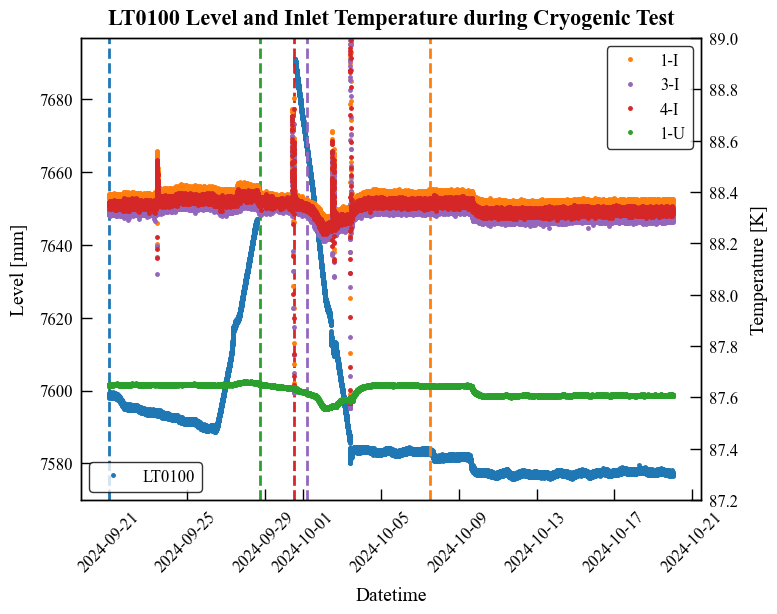

In [481]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.legend(loc="lower left")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes2 = axes.twinx()
axes2.plot(pipe.sensors[49319].data.index, pipe.sensors[49319].data.values, ".", label=fr"{pipe.sensors[49319].name}", color="tab:orange")
axes2.plot(pipe.sensors[49321].data.index, pipe.sensors[49321].data.values, ".", label=fr"{pipe.sensors[49321].name}", color="tab:purple")
axes2.plot(pipe.sensors[49322].data.index, pipe.sensors[49322].data.values, ".", label=fr"{pipe.sensors[49322].name}", color="tab:red")
axes2.plot(pipe.sensors[39671].data.index, pipe.sensors[39671].data.values, ".", label=fr"{pipe.sensors[39671].name}", color="tab:green")
axes2.legend(loc="best", ncol=1)
axes2.set_ylabel("Temperature [K]")
axes2.set_ylim(87.2, 89)
axes.set_title("LT0100 Level and Inlet Temperature during Cryogenic Test")
axes.axvline(t1, color="tab:blue", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes.axvline(t3, color="tab:green", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes.axvline(t4, color="tab:red", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes.axvline(t5, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes.axvline(t6, color="tab:orange", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes.tick_params(axis='x', rotation=45)

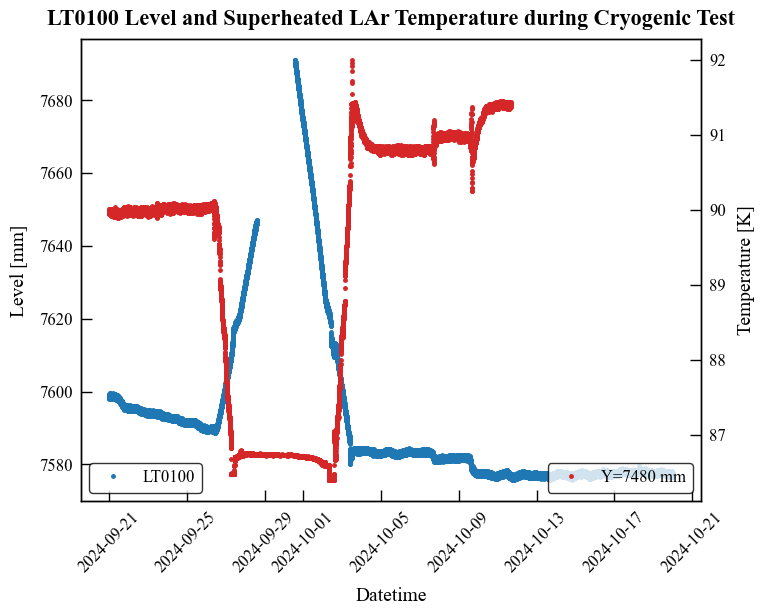

In [48]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.legend(loc="lower left")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes2 = axes.twinx()
# axes2.plot(ga1.sensors[5].data.index, ga1.sensors[5].data.values, ".", label=fr"Y={ga1.sensors[5].Y:.0f} mm", color="tab:orange")
axes2.plot(hawai.sensors[40020].data.index, hawai.sensors[40020].data.values, ".", label=fr"Y={hawai.sensors[40020].Y:.0f} mm", color="tab:red")
axes2.legend(loc="lower right")
axes2.set_ylabel("Temperature [K]")
axes.set_title("LT0100 Level and Superheated LAr Temperature during Cryogenic Test")
axes.tick_params(axis='x', rotation=45)

(86.0, 87.0)

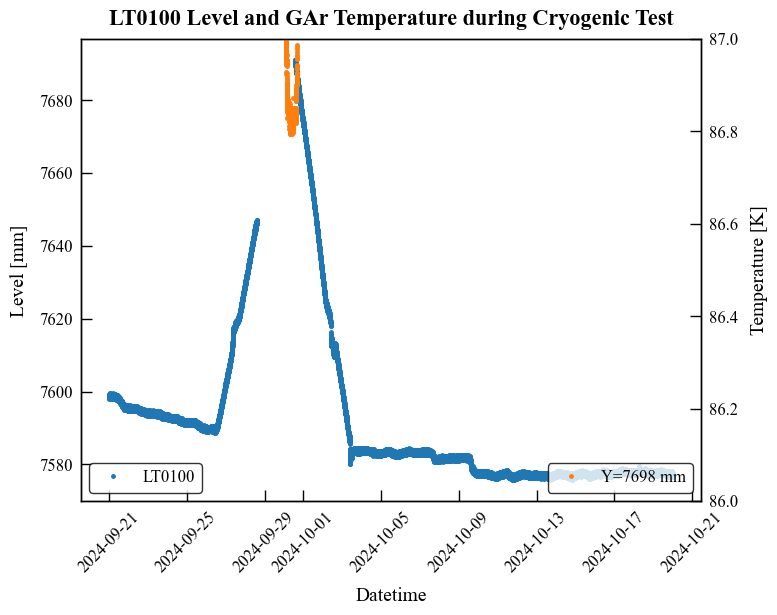

In [62]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.legend(loc="lower left")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes2 = axes.twinx()
axes2.plot(ga1.sensors[6].data.index, ga1.sensors[6].data.values, ".", label=fr"Y={ga1.sensors[6].Y:.0f} mm", color="tab:orange")
axes2.legend(loc="lower right")
axes2.set_ylabel("Temperature [K]")
axes.set_title("LT0100 Level and GAr Temperature during Cryogenic Test")
axes.tick_params(axis='x', rotation=45)
axes2.set_ylim(86,87)